# HY Corporate Default Risk — Full Analysis Pipeline (v4)
**Study:** Predicting Corporate Default Risk in US High Yield Firms Using Machine Learning

### Changes in v4
- **Workflow corrected:** Data Cleaning → EDA → Feature Engineering → Modelling
- **Change variables:** Raw lags replaced with year-on-year change (VARIABLE - VARIABLE_lag1)
- **Lag-2 removed:** Only 1-year change variables retained to minimise data loss
- **QR:** Pre-calculated from FactSet — no recomputation
- **SHAP fixed:** LinearExplainer for LR, TreeExplainer for tree models
- **Visualizations substantially improved:** Distribution plots, trend analysis, pairplots, heatmaps

### Research Questions
| RQ | Question | Method |
|---|---|---|
| RQ1 | Do ML ensembles outperform Altman Z-score and LR? | DeLong test on Set 1 |
| RQ2 | Does Distance to Default improve ML performance? | DeLong test Set1 vs Set2 |
| RQ3 | Does macroeconomic data improve ML performance? | DeLong test Set2 vs Set3 |
| RQ4 | Which features drive predictions? | SHAP on best model |

## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## Cell 2 — Install Packages

In [ ]:
!pip install fredapi scikit-learn xgboost lightgbm imbalanced-learn shap --quiet
print("Packages installed.")

Packages installed.


## Cell 3 — Imports & Configuration

In [ ]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from difflib import get_close_matches
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

BASE         = '/content/drive/MyDrive/DBA/Research'
DATA         = f'{BASE}/data'
OUTPUT       = f'{BASE}/outputs'
PANEL_FILE   = f'{DATA}/panel_data_prelim.xlsx'
LOPUCKI_FILE = f'{DATA}/Florida-UCLA-LoPucki Bankruptcy Research Database 1-12-2023.csv'
FRED_API_KEY = '9310e4faefd94a6352fdb7551dba5982'

TRAIN_END  = 2017
TEST_START = 2018

os.makedirs(OUTPUT, exist_ok=True)

C_DEF   = '#C00000'   # red — defaulted
C_NODEF = '#2E75B6'   # blue — non-defaulted
C_NEUT  = '#70AD47'   # green — neutral
C_WARN  = '#FF8C00'   # orange — warning/rate

print(f"Base  exists: {os.path.exists(BASE)}")
print(f"Data  exists: {os.path.exists(DATA)}")
print(f"Panel exists: {os.path.exists(PANEL_FILE)}")

Base  exists: True
Data  exists: True
Panel exists: True


---
# SECTION A — DATA CLEANING

## Step 1 — Load Raw Data

In [ ]:
print("="*55)
print("STEP 1: LOADING RAW DATA")
print("="*55)

panel_raw = pd.read_excel(PANEL_FILE, header=2)
panel     = panel_raw.iloc[2:].copy()

# Columns mapped by POSITION — not by Excel header text
# Column K = QR (Quick Ratio, pre-calculated by FactSet)
panel.columns = [
    'Ticker','Company_Name','Year',
    'Revenue','Gross_Profit','EBITDA','Net_Profit',
    'Total_Assets','Fixed_Assets','Current_Assets',
    'QR',                   # K — pre-calculated Quick Ratio from FactSet
    'Total_Liabilities','Current_Liabilities','LT_Liabilities',
    'Total_Equity','LT_Funds',
    'Market_Cap','Share_Price','Equity_Vol',
    'Interest_Expense','Free_Cash_Flow','Operating_CF',
    'Credit_Rating','OAS',
    'GDP_Growth','Treasury_10Y','Treasury_2Y','HY_OAS','CPI'
]

lop = pd.read_csv(LOPUCKI_FILE, encoding='latin1', low_memory=False)
print(f"FactSet rows:  {len(panel):,}")
print(f"LoPucki rows:  {len(lop):,}")
print(f"Column K mapped directly as QR (pre-calculated Quick Ratio)")

STEP 1: LOADING RAW DATA
FactSet rows:  6,262
LoPucki rows:  1,218
Column K mapped directly as QR (pre-calculated Quick Ratio)


## Step 2 — Fix Data Types

In [ ]:
print("="*55)
print("STEP 2: FIXING DATA TYPES")
print("="*55)

panel['Year'] = pd.to_numeric(panel['Year'], errors='coerce')
panel = panel[panel['Year'].notna()].copy()
panel['Year'] = panel['Year'].astype(int)
panel['Company_Name'] = panel['Company_Name'].astype(str).str.strip()
panel['Ticker']       = panel['Ticker'].astype(str).str.strip()

fin_cols = [
    'Revenue','Gross_Profit','EBITDA','Net_Profit',
    'Total_Assets','Fixed_Assets','Current_Assets','QR',
    'Total_Liabilities','Current_Liabilities','LT_Liabilities',
    'Total_Equity','LT_Funds','Market_Cap','Share_Price','Equity_Vol',
    'Interest_Expense','Free_Cash_Flow','Operating_CF'
]
for col in fin_cols:
    panel[col] = pd.to_numeric(panel[col], errors='coerce')

print(f"Rows: {len(panel):,} | Years: {panel.Year.min()}-{panel.Year.max()} | Firms: {panel.Ticker.nunique()}")

STEP 2: FIXING DATA TYPES
Rows: 6,262 | Years: 2000-2022 | Firms: 412


## Step 3 — Remove Completely Empty Rows

In [ ]:
print("="*55)
print("STEP 3: REMOVING EMPTY ROWS")
print("="*55)

before = len(panel)
key_cols = ['Total_Assets','EBITDA','Net_Profit','Revenue','Total_Liabilities']
panel = panel[panel[key_cols].notna().any(axis=1)].copy()
print(f"Removed: {before-len(panel):,} empty rows")
print(f"Remaining: {len(panel):,} | Firms: {panel.Ticker.nunique()}")

STEP 3: REMOVING EMPTY ROWS
Removed: 3,178 empty rows
Remaining: 3,084 | Firms: 242


## Step 4 — Handle Negative Values

In [ ]:
print("="*55)
print("STEP 4: HANDLING NEGATIVE VALUES")
print("="*55)

for col in ['Total_Assets','Revenue','Current_Assets','Fixed_Assets','Gross_Profit']:
    n = (panel[col] < 0).sum()
    if n > 0:
        panel.loc[panel[col]<0, col] = np.nan
        print(f"  {col:<25}: {n} set to NaN (definitionally impossible)")

n_ie = (panel['Interest_Expense'] < 0).sum()
panel['Interest_Expense'] = panel['Interest_Expense'].abs()
print(f"  {'Interest_Expense':<25}: {n_ie} converted to absolute value")

legitimate = ['Total_Equity','Net_Profit','EBITDA','LT_Liabilities',
              'Free_Cash_Flow','Operating_CF']
for col in legitimate:
    n = (panel[col] < 0).sum()
    print(f"  {col:<25}: {n} negatives KEPT (legitimate — e.g. distressed firms)")

STEP 4: HANDLING NEGATIVE VALUES
  Revenue                  : 1 set to NaN (definitionally impossible)
  Current_Assets           : 1 set to NaN (definitionally impossible)
  Gross_Profit             : 119 set to NaN (definitionally impossible)
  Interest_Expense         : 1 converted to absolute value
  Total_Equity             : 277 negatives KEPT (legitimate — e.g. distressed firms)
  Net_Profit               : 1072 negatives KEPT (legitimate — e.g. distressed firms)
  EBITDA                   : 211 negatives KEPT (legitimate — e.g. distressed firms)
  LT_Liabilities           : 0 negatives KEPT (legitimate — e.g. distressed firms)
  Free_Cash_Flow           : 1053 negatives KEPT (legitimate — e.g. distressed firms)
  Operating_CF             : 424 negatives KEPT (legitimate — e.g. distressed firms)


## Step 5 — Compute Financial Ratios (Mushtaq Ahmad et al. 2026)

In [ ]:
print("="*55)
print("STEP 5: COMPUTING FINANCIAL RATIOS")
print("="*55)

p = panel.copy()

def sd(a, b):
    return np.where((pd.isna(b))|(b==0), np.nan, a/b)

# ── PROFITABILITY ──────────────────────────────────────────────────────────────
p['EBITDAFE'] = sd(p['EBITDA'],       p['Interest_Expense'])
p['EBITDATA'] = sd(p['EBITDA'],       p['Total_Assets'])
p['EBITDAEQ'] = sd(p['EBITDA'],       p['Total_Equity'])
p['EBITDASA'] = sd(p['EBITDA'],       p['Revenue'])
p['NPSA']     = sd(p['Net_Profit'],   p['Revenue'])
p['GPSA']     = sd(p['Gross_Profit'], p['Revenue'])
p['NITA']     = sd(p['Net_Profit'],   p['Total_Assets'])
p['NITE']     = sd(p['Net_Profit'],   p['Total_Equity'])
p['EBITTA']   = p['EBITDATA'].copy()
# LNNI DROPPED — biased missingness toward distressed firms
# NPEMP, INVTO, RECTO DROPPED — data unavailable

# ── LEVERAGE ──────────────────────────────────────────────────────────────────
p['EQTA']   = sd(p['Total_Equity'],      p['Total_Assets'])
p['EQFA']   = sd(p['Total_Equity'],      p['Fixed_Assets'])
p['EQLIAB'] = sd(p['Total_Equity'],      p['Total_Liabilities'])
p['LIABTA'] = sd(p['Total_Liabilities'], p['Total_Assets'])
p['LTLTA']  = sd(p['LT_Liabilities'],    p['Total_Assets'])
p['LTFFA']  = sd(p['LT_Funds'],          p['Fixed_Assets'])
p['DE']     = sd(p['Total_Liabilities'], p['Total_Equity'])

# ── LIQUIDITY & CASH FLOW ─────────────────────────────────────────────────────
p['CFEQ']  = sd(p['Operating_CF'], p['Total_Equity'])
p['CFTA']  = sd(p['Operating_CF'], p['Total_Assets'])
p['CFSA']  = sd(p['Operating_CF'], p['Revenue'])
p['OCACL'] = sd(p['Operating_CF'], p['Current_Liabilities'])
p['CR']    = sd(p['Current_Assets'], p['Current_Liabilities'])
# QR — pre-calculated by FactSet, no computation needed

# ── FIRM SIZE ─────────────────────────────────────────────────────────────────
p['LNTA'] = np.where(p['Total_Assets']>0, np.log(p['Total_Assets']), np.nan)
p['LNSA'] = np.where(p['Revenue']>0,      np.log(p['Revenue']),      np.nan)
p['SATA'] = sd(p['Revenue'], p['Total_Assets'])

# ── GROWTH ────────────────────────────────────────────────────────────────────
p = p.sort_values(['Ticker','Year']).reset_index(drop=True)
p['SG']       = p.groupby('Ticker')['Revenue'].pct_change()
p['EBITDA_G'] = p.groupby('Ticker')['EBITDA'].pct_change()
p['CFG']      = p.groupby('Ticker')['Operating_CF'].pct_change()
p['EQG']      = p.groupby('Ticker')['Total_Equity'].pct_change()
p['NPG']      = p.groupby('Ticker')['Net_Profit'].pct_change()

print("Base ratios computed: 30 variables")
print("QR: read directly from FactSet (pre-calculated)")

STEP 5: COMPUTING FINANCIAL RATIOS
Base ratios computed: 30 variables
QR: read directly from FactSet (pre-calculated)


## Step 5b — Change Variables (Year-on-Year Trajectory)
Replaces raw lags. Captures financial deterioration direction without introducing multicollinearity.

In [ ]:
print("="*55)
print("STEP 5b: CHANGE VARIABLES")
print("="*55)

# Year-on-year change = current - prior year
# Captures trajectory (is leverage rising? is profitability falling?)
# without adding the collinearity of raw lagged values

CHANGE_VARS = ['NITA','NPSA','EQFA','EBITDAFE','LIABTA','CFTA']
for var in CHANGE_VARS:
    lag1 = p.groupby('Ticker')[var].shift(1)
    p[f'{var}_chg'] = p[var] - lag1

CHANGE_FEATURES = [f'{v}_chg' for v in CHANGE_VARS]

print("Change variables added (current year minus prior year):")
for f in CHANGE_FEATURES:
    avail = p[f].notna().mean()*100
    print(f"  {f:<20}: {avail:.1f}% available")

print(f"\nNote: Change variable loses only the first year per firm")
print(f"      vs raw lag which also creates multicollinearity with base variable")

STEP 5b: CHANGE VARIABLES
Change variables added (current year minus prior year):
  NITA_chg            : 90.4% available
  NPSA_chg            : 91.0% available
  EQFA_chg            : 85.0% available
  EBITDAFE_chg        : 83.2% available
  LIABTA_chg          : 89.9% available
  CFTA_chg            : 90.0% available

Note: Change variable loses only the first year per firm
      vs raw lag which also creates multicollinearity with base variable


## Step 5c — Altman Z-Score (Raw, Unwinsorized — Benchmark Only)

In [ ]:
p['altman_x1'] = sd(p['Current_Assets']-p['Current_Liabilities'], p['Total_Assets'])
p['altman_x2'] = sd(p['Total_Equity'],   p['Total_Assets'])
p['altman_x3'] = p['EBITDATA'].copy()
p['altman_x4'] = sd(p['Market_Cap'],     p['Total_Liabilities'])
p['altman_x5'] = p['SATA'].copy()

p['altman_zscore_raw'] = (
    1.2*p['altman_x1'].fillna(0) + 1.4*p['altman_x2'].fillna(0) +
    3.3*p['altman_x3'].fillna(0) + 0.6*p['altman_x4'].fillna(0) +
    1.0*p['altman_x5'].fillna(0)
)
all_miss = p[['altman_x1','altman_x2','altman_x3','altman_x4','altman_x5']].isna().all(axis=1)
p.loc[all_miss,'altman_zscore_raw'] = np.nan
print(f"Altman Z-score computed (unwinsorized for benchmark comparison)")
print(f"Available: {p['altman_zscore_raw'].notna().mean()*100:.1f}%")

Altman Z-score computed (unwinsorized for benchmark comparison)
Available: 98.5%


## Step 5d — Merton Distance to Default (Bharath & Shumway 2008)

In [ ]:
def compute_dd(row):
    E, D, sigma = row['Market_Cap'], row['Total_Liabilities'], row['Equity_Vol']
    if any(pd.isna(x) for x in [E,D,sigma]): return np.nan
    if D<=0 or E<=0 or sigma<=0: return np.nan
    try:
        s = sigma/100.0 if sigma>1 else sigma
        return (np.log((E+D)/D) + (-0.5*s**2)) / s
    except: return np.nan

p['distance_to_default'] = p.apply(compute_dd, axis=1)
print(f"Distance to Default: {p['distance_to_default'].notna().mean()*100:.1f}% available")
print(f"Mean: {p['distance_to_default'].mean():.2f} | Std: {p['distance_to_default'].std():.2f}")

Distance to Default: 77.2% available
Mean: 1.77 | Std: 2.21


## Step 6 — Winsorize (1st and 99th Percentile)

In [ ]:
print("="*55)
print("STEP 6: WINSORIZING")
print("="*55)

RATIO_VARS = [
    'EBITDAFE','EBITDATA','EBITDAEQ','EBITDASA','NPSA','GPSA','NITA','NITE','EBITTA',
    'EQTA','EQFA','EQLIAB','LIABTA','LTLTA','LTFFA','DE',
    'CFEQ','CFTA','CFSA','OCACL','CR','QR','LNTA','LNSA','SATA',
    'SG','EBITDA_G','CFG','EQG','NPG'
] + CHANGE_FEATURES

WIN_COLS = RATIO_VARS + [
    'altman_x1','altman_x2','altman_x3','altman_x4','altman_x5',
    'distance_to_default'
]
for col in WIN_COLS:
    if col in p.columns:
        lb = p[col].quantile(0.01)
        ub = p[col].quantile(0.99)
        p[col] = p[col].clip(lower=lb, upper=ub)

print(f"Winsorized {len(WIN_COLS)} variables at 1st/99th percentile")
print("altman_zscore_raw kept unwinsorized for benchmark comparison")

STEP 6: WINSORIZING
Winsorized 42 variables at 1st/99th percentile
altman_zscore_raw kept unwinsorized for benchmark comparison


## Step 7 — Create Default Flag (Forward-Looking, LoPucki)

In [ ]:
print("="*55)
print("STEP 7: DEFAULT FLAG")
print("="*55)

lop['DateFiled']      = pd.to_datetime(lop['DateFiled'], errors='coerce')
lop['YearFiled']      = lop['DateFiled'].dt.year
lop['AssetsPetition'] = pd.to_numeric(lop['AssetsPetition'], errors='coerce')
lop_study = lop[
    (lop['YearFiled']>=2000)&(lop['YearFiled']<=2022)&
    (lop['AssetsPetition']>=100)
].copy()

panel_names = set(p['Company_Name'].str.lower().str.strip())
default_set = set()
for _, row in lop_study.iterrows():
    nc = str(row['NameCorp']).lower().strip()
    if nc in panel_names:
        default_set.add((nc, int(row['YearFiled'])))
    else:
        m = get_close_matches(nc, panel_names, n=1, cutoff=0.75)
        if m: default_set.add((m[0], int(row['YearFiled'])))

p['y_default'] = p.apply(
    lambda r: 1 if (str(r['Company_Name']).lower().strip(),
                    int(r['Year'])+1) in default_set else 0, axis=1)

print(f"Default events (Y=1): {p.y_default.sum():,} ({p.y_default.mean()*100:.2f}%)")
print(f"Non-default   (Y=0):  {(p.y_default==0).sum():,}")

STEP 7: DEFAULT FLAG
Default events (Y=1): 154 (4.99%)
Non-default   (Y=0):  2,930


## Step 8 — Handle Missing Data

In [ ]:
print("="*55)
print("STEP 8: MISSING DATA")
print("="*55)

key_fin = ['EBITDATA','LIABTA','CR','NITA','LNTA','SATA']
before  = len(p)
miss_pct = p.groupby('Ticker')[key_fin].apply(lambda x: x.isna().mean().mean())
drop_firms = miss_pct[miss_pct > 0.5].index
p = p[~p['Ticker'].isin(drop_firms)].copy()
print(f"Firms dropped (>50% missing on key vars): {len(drop_firms)}")
print(f"Firm-years: {before:,} -> {len(p):,}")
print(f"Unique firms remaining: {p.Ticker.nunique()}")

STEP 8: MISSING DATA
Firms dropped (>50% missing on key vars): 1
Firm-years: 3,084 -> 3,083
Unique firms remaining: 241


---
# SECTION B — EXPLORATORY DATA ANALYSIS
EDA runs after data cleaning and before modelling. Findings here inform feature selection and modelling decisions.

## EDA 1 — Dataset Overview and Default Distribution

EDA 1: DATASET OVERVIEW
Total firm-years:  3,083
Unique firms:      241
Year range:        2000 - 2022
Default rate:      5.00%
Default events:    154
Non-default:       2,929


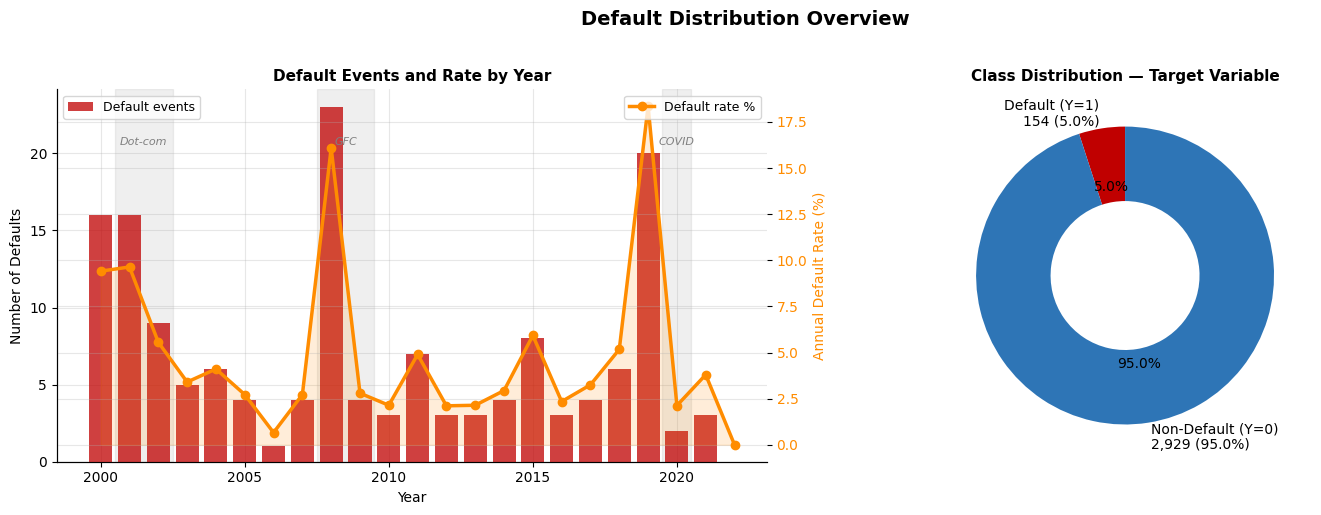

Saved: eda_01_default_overview.png


In [ ]:
print("="*55)
print("EDA 1: DATASET OVERVIEW")
print("="*55)

print(f"Total firm-years:  {len(p):,}")
print(f"Unique firms:      {p.Ticker.nunique():,}")
print(f"Year range:        {p.Year.min()} - {p.Year.max()}")
print(f"Default rate:      {p.y_default.mean()*100:.2f}%")
print(f"Default events:    {p.y_default.sum():,}")
print(f"Non-default:       {(p.y_default==0).sum():,}")

# ── Figure 1: Default overview — 2 panels ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Default Distribution Overview', fontsize=14, fontweight='bold', y=1.02)

# Left: Events and rate by year
ax = axes[0]
yr_d = p[p.y_default==1].groupby('Year').size()
yr_t = p.groupby('Year').size()
yr_r = (yr_d/yr_t*100).fillna(0)

bars = ax.bar(yr_d.index, yr_d.values, color=C_DEF, alpha=0.75, label='Default events', zorder=3)
ax2  = ax.twinx()
ax2.plot(yr_r.index, yr_r.values, 'o-', color=C_WARN, lw=2.5, ms=6,
         label='Default rate %', zorder=4)
ax2.fill_between(yr_r.index, yr_r.values, alpha=0.15, color=C_WARN)
ax2.set_ylabel('Annual Default Rate (%)', color=C_WARN, fontsize=10)
ax2.tick_params(axis='y', labelcolor=C_WARN)

# Shade recession years
for yr_start, yr_end, label in [(2001,2002,'Dot-com'),(2008,2009,'GFC'),(2020,2020,'COVID')]:
    ax.axvspan(yr_start-0.5, yr_end+0.5, alpha=0.12, color='grey', zorder=1)
    ax.text((yr_start+yr_end)/2, ax.get_ylim()[1]*0.85, label,
            ha='center', fontsize=8, color='grey', style='italic')

ax.set_title('Default Events and Rate by Year', fontweight='bold', fontsize=11)
ax.set_xlabel('Year'); ax.set_ylabel('Number of Defaults', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

# Right: Pie / donut of class balance
ax = axes[1]
sizes = [p.y_default.sum(), (p.y_default==0).sum()]
labels= [f'Default (Y=1)\n{sizes[0]:,} ({p.y_default.mean()*100:.1f}%)',
         f'Non-Default (Y=0)\n{sizes[1]:,} ({(1-p.y_default.mean())*100:.1f}%)']
colors= [C_DEF, C_NODEF]
wedges, texts, autos = ax.pie(sizes, labels=labels, colors=colors,
                               autopct='%1.1f%%', startangle=90,
                               wedgeprops=dict(width=0.5),
                               textprops={'fontsize':10})
ax.set_title('Class Distribution — Target Variable', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_01_default_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: eda_01_default_overview.png")

## EDA 2 — Descriptive Statistics and Statistical Tests

In [ ]:
print("="*55)
print("EDA 2: DESCRIPTIVE STATISTICS")
print("="*55)

KEY_VARS = {
    'LIABTA':          'Liabilities / Total Assets',
    'EBITDAFE':        'EBITDA / Interest Expense',
    'CR':              'Current Ratio',
    'QR':              'Quick Ratio',
    'NITA':            'Net Profit / Total Assets',
    'EBITDASA':        'EBITDA / Sales',
    'CFTA':            'Operating CF / Total Assets',
    'LNTA':            'Log Total Assets',
    'altman_zscore_raw':'Altman Z-Score',
    'distance_to_default':'Distance to Default',
}

desc0 = p[p.y_default==0][list(KEY_VARS)].describe().T
desc1 = p[p.y_default==1][list(KEY_VARS)].describe().T

print(f"{'Variable':<22} {'Mean_Y0':>10} {'Med_Y0':>9} {'Mean_Y1':>10} {'Med_Y1':>9} {'MW p-val':>10} {'Sig':>5}")
print('-'*80)

test_results = []
for var, label in KEY_VARS.items():
    g0 = p[p.y_default==0][var].dropna()
    g1 = p[p.y_default==1][var].dropna()
    if len(g0)>5 and len(g1)>5:
        # Mann-Whitney U (non-parametric — more appropriate for financial ratios)
        stat, pv = mannwhitneyu(g0, g1, alternative='two-sided')
        sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        print(f"{label[:22]:<22} {g0.mean():>10.3f} {g0.median():>9.3f} "
              f"{g1.mean():>10.3f} {g1.median():>9.3f} {pv:>10.4f} {sig:>5}")
        test_results.append({'Variable':label,'Mean_Y0':g0.mean(),'Median_Y0':g0.median(),
                              'Mean_Y1':g1.mean(),'Median_Y1':g1.median(),
                              'MW_pvalue':pv,'Sig':sig})

pd.DataFrame(test_results).to_csv(f'{OUTPUT}/eda_descriptive_stats.csv', index=False)
print('\n* p<0.05  ** p<0.01  *** p<0.001  (Mann-Whitney U test)')
print('Saved: eda_descriptive_stats.csv')

EDA 2: DESCRIPTIVE STATISTICS
Variable                  Mean_Y0    Med_Y0    Mean_Y1    Med_Y1   MW p-val   Sig
--------------------------------------------------------------------------------
Liabilities / Total As      0.702     0.698      0.904     0.867     0.0000   ***
EBITDA / Interest Expe     13.532     4.365      3.135     1.510     0.0000   ***
Current Ratio               1.937     1.387      1.517     1.114     0.0001   ***
Quick Ratio                 1.461     1.042      1.123     0.896     0.0002   ***
Net Profit / Total Ass     -0.006     0.019     -0.152    -0.086     0.0000   ***
EBITDA / Sales              0.222     0.199      0.132     0.110     0.0000   ***
Operating CF / Total A      0.067     0.068      0.028     0.031     0.0000   ***
Log Total Assets            8.016     8.074      7.543     7.412     0.0000   ***
Altman Z-Score              2.559     1.897      1.206     1.109     0.0000   ***
Distance to Default         1.845     1.365      0.260    -0.237     

## EDA 3 — Variable Distributions by Default Status

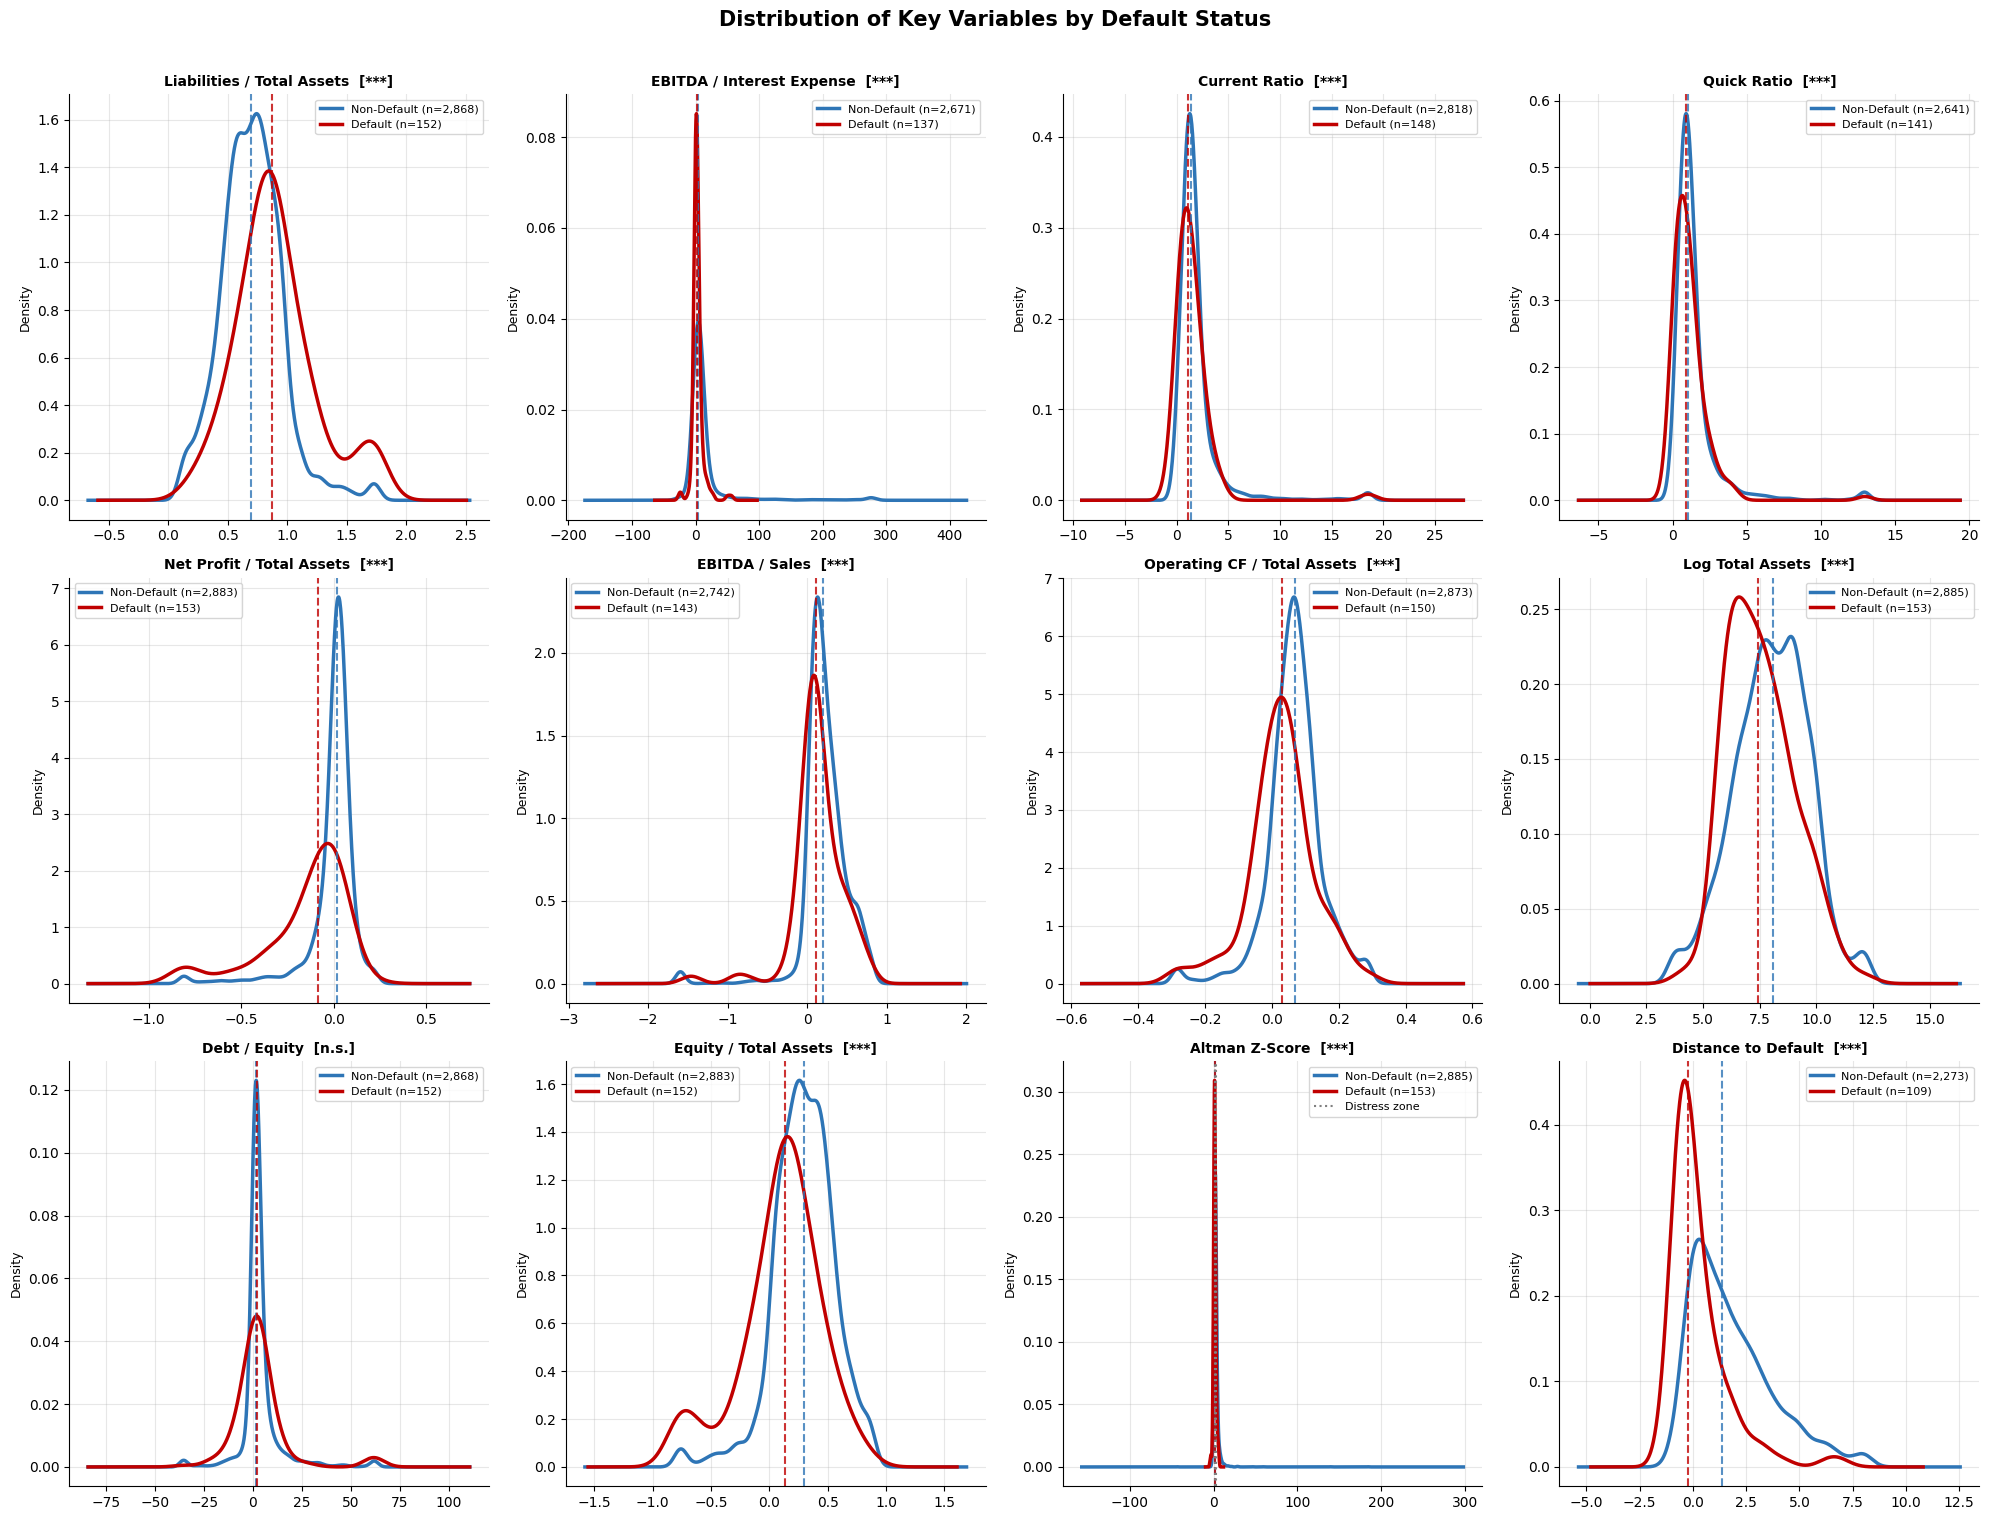

Saved: eda_02_distributions.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
fig.suptitle('Distribution of Key Variables by Default Status',
             fontsize=15, fontweight='bold', y=1.01)

plot_vars = [
    ('LIABTA',          'Liabilities / Total Assets'),
    ('EBITDAFE',        'EBITDA / Interest Expense'),
    ('CR',              'Current Ratio'),
    ('QR',              'Quick Ratio'),
    ('NITA',            'Net Profit / Total Assets'),
    ('EBITDASA',        'EBITDA / Sales'),
    ('CFTA',            'Operating CF / Total Assets'),
    ('LNTA',            'Log Total Assets'),
    ('DE',              'Debt / Equity'),
    ('EQTA',            'Equity / Total Assets'),
    ('altman_zscore_raw','Altman Z-Score'),
    ('distance_to_default','Distance to Default'),
]

for ax, (var, title) in zip(axes, plot_vars):
    d0 = p[p.y_default==0][var].dropna()
    d1 = p[p.y_default==1][var].dropna()

    # KDE overlay
    if len(d0)>10 and d0.std()>0:
        d0.plot.kde(ax=ax, color=C_NODEF, lw=2.5, label=f'Non-Default (n={len(d0):,})')
    if len(d1)>5 and d1.std()>0:
        d1.plot.kde(ax=ax, color=C_DEF,   lw=2.5, label=f'Default (n={len(d1):,})')

    # Vertical lines for medians
    ax.axvline(d0.median(), color=C_NODEF, ls='--', lw=1.5, alpha=0.8)
    ax.axvline(d1.median(), color=C_DEF,   ls='--', lw=1.5, alpha=0.8)

    # Altman distress zone
    if var == 'altman_zscore_raw':
        ax.axvline(1.81, color='grey', ls=':', lw=1.5, label='Distress zone')
        ax.axvline(2.99, color='grey', ls=':', lw=1.5)

    # Mann-Whitney significance
    if len(d0)>5 and len(d1)>5:
        _, pv = mannwhitneyu(d0, d1, alternative='two-sided')
        sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        ax.set_title(f'{title}  [{sig}]', fontweight='bold', fontsize=10)
    else:
        ax.set_title(title, fontweight='bold', fontsize=10)

    ax.legend(fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_02_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_02_distributions.png")

## EDA 4 — Box Plots with Significance Annotations

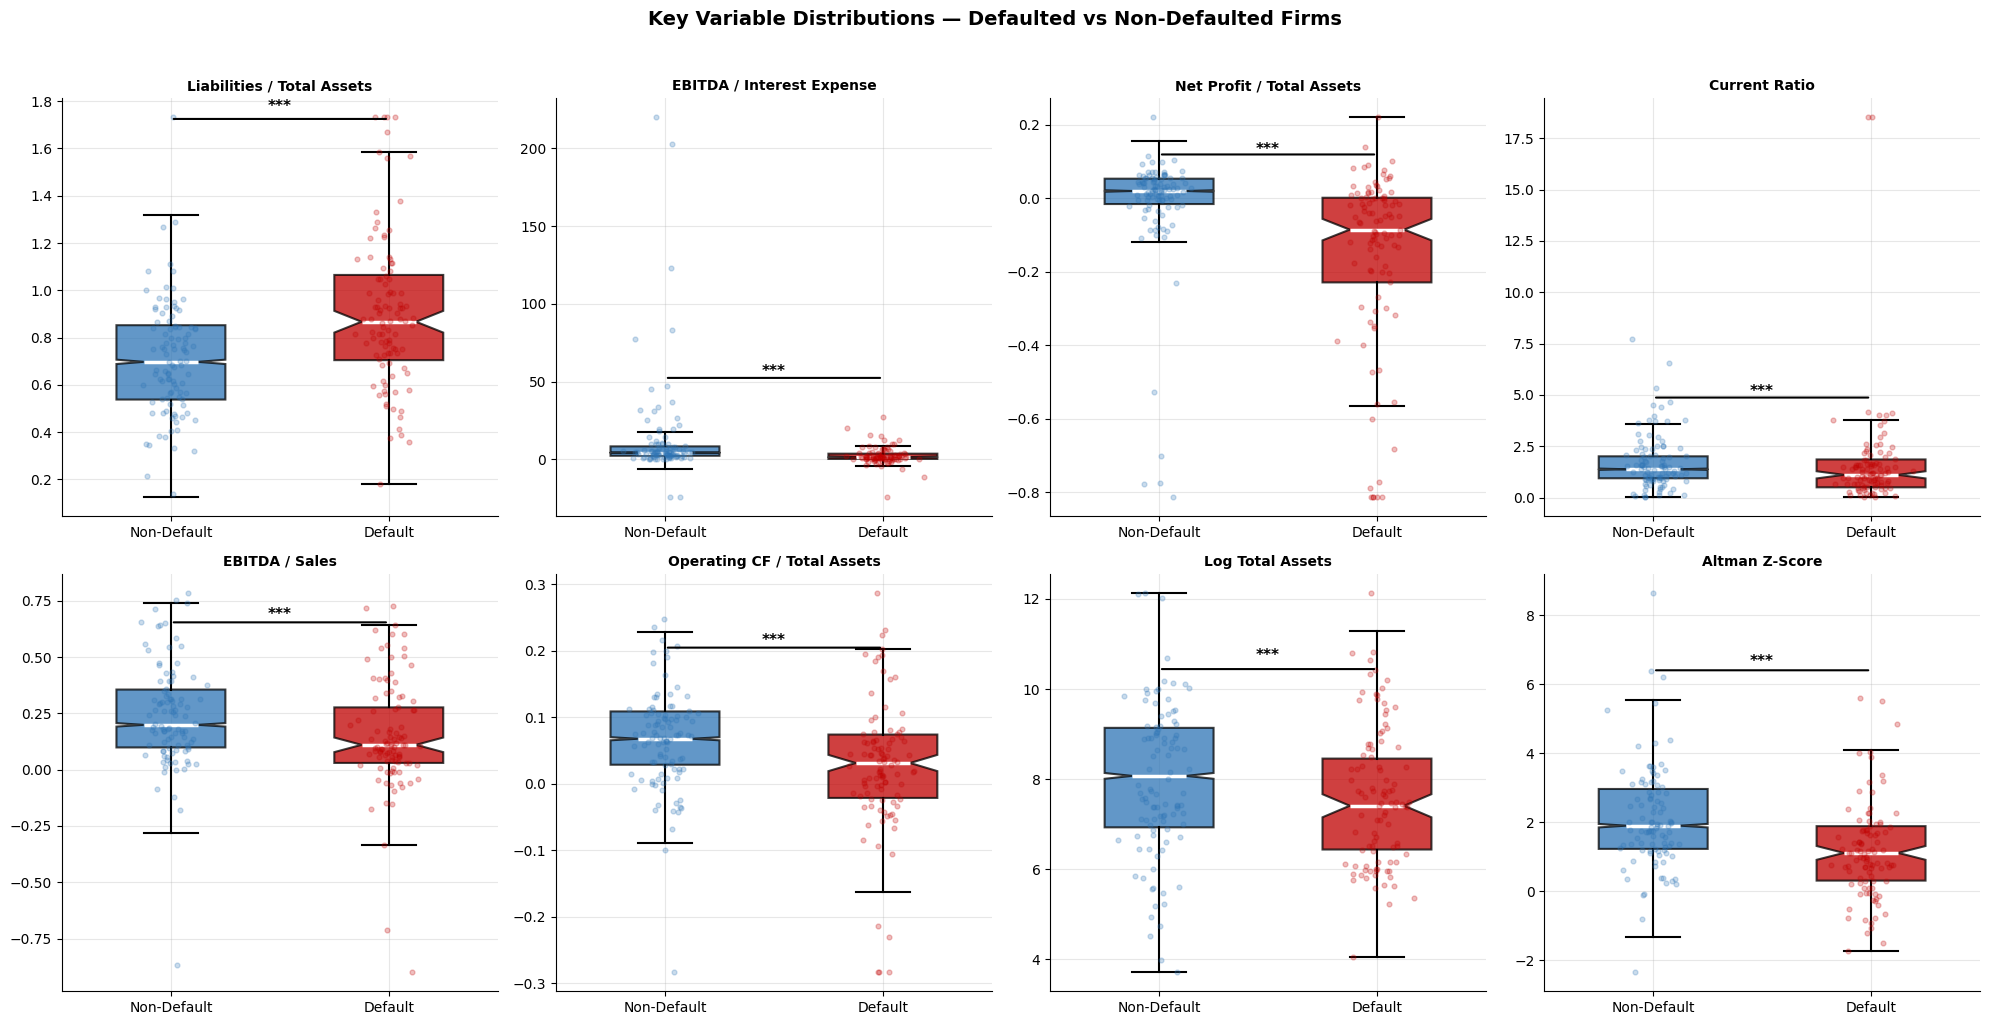

Saved: eda_03_boxplots.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
fig.suptitle('Key Variable Distributions — Defaulted vs Non-Defaulted Firms',
             fontsize=14, fontweight='bold', y=1.02)

box_vars = [
    ('LIABTA','Liabilities / Total Assets'),
    ('EBITDAFE','EBITDA / Interest Expense'),
    ('NITA','Net Profit / Total Assets'),
    ('CR','Current Ratio'),
    ('EBITDASA','EBITDA / Sales'),
    ('CFTA','Operating CF / Total Assets'),
    ('LNTA','Log Total Assets'),
    ('altman_zscore_raw','Altman Z-Score'),
]

for ax, (var, title) in zip(axes, box_vars):
    d0 = p[p.y_default==0][var].dropna()
    d1 = p[p.y_default==1][var].dropna()

    bp = ax.boxplot([d0, d1], patch_artist=True, notch=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    boxprops=dict(linewidth=1.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    bp['boxes'][0].set_facecolor(C_NODEF); bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(C_DEF);   bp['boxes'][1].set_alpha(0.75)

    # Add individual points (jittered) for small groups
    for i, (d, c) in enumerate([(d0,C_NODEF),(d1,C_DEF)], 1):
        sample = d.sample(min(100,len(d)), random_state=42)
        ax.scatter(np.random.normal(i, 0.06, len(sample)), sample,
                   alpha=0.25, s=12, color=c, zorder=3)

    # Significance annotation
    if len(d0)>5 and len(d1)>5:
        _, pv = mannwhitneyu(d0, d1, alternative='two-sided')
        sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        y_max = max(d0.quantile(0.95), d1.quantile(0.95))
        ax.annotate('', xy=(2, y_max), xytext=(1, y_max),
                    arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
        ax.text(1.5, y_max*1.02, sig, ha='center', fontsize=11, fontweight='bold')

    ax.set_xticks([1,2])
    ax.set_xticklabels(['Non-Default','Default'], fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_03_boxplots.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_03_boxplots.png")

## EDA 5 — Correlation Heatmap

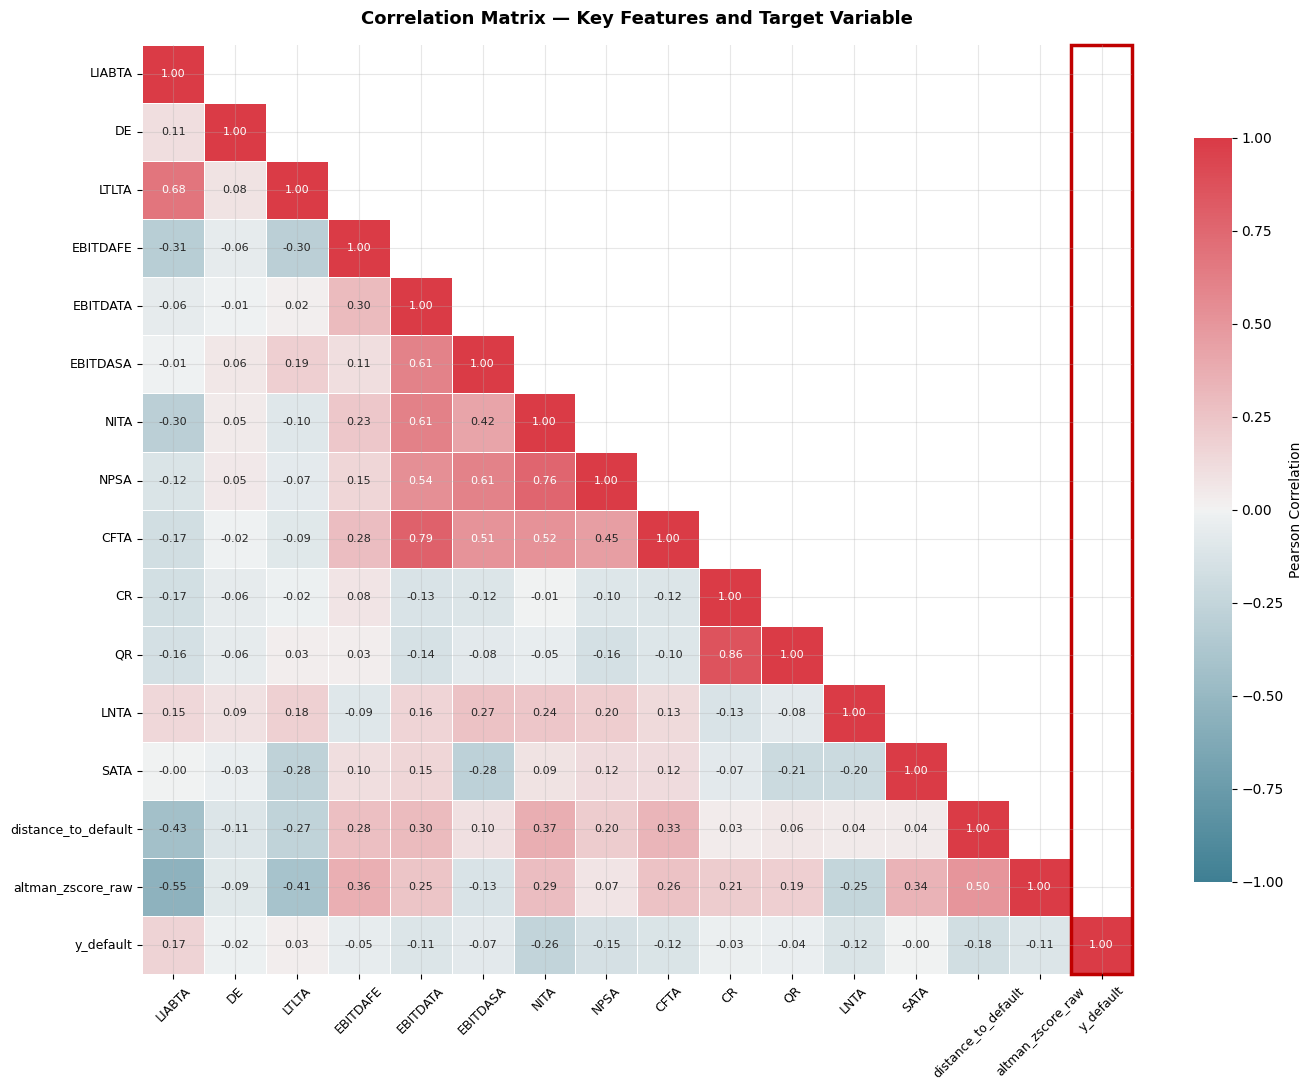

Saved: eda_04_correlation.png


In [ ]:
corr_vars = [
    'LIABTA','DE','LTLTA','EBITDAFE','EBITDATA','EBITDASA',
    'NITA','NPSA','CFTA','CR','QR','LNTA','SATA',
    'distance_to_default','altman_zscore_raw','y_default'
]
corr_vars = [v for v in corr_vars if v in p.columns]
corr_df   = p[corr_vars].dropna()
corr      = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size':8}, linewidths=0.5,
            cbar_kws={'shrink':0.8, 'label':'Pearson Correlation'})

ax.set_title('Correlation Matrix — Key Features and Target Variable',
             fontweight='bold', fontsize=13, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

# Highlight target variable row/col
ax.add_patch(plt.Rectangle((len(corr_vars)-1, 0), 1, len(corr_vars),
                             fill=False, edgecolor='#C00000', lw=2.5, clip_on=False))

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_04_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_04_correlation.png")

## EDA 6 — Financial Ratio Trends Over Time by Default Status

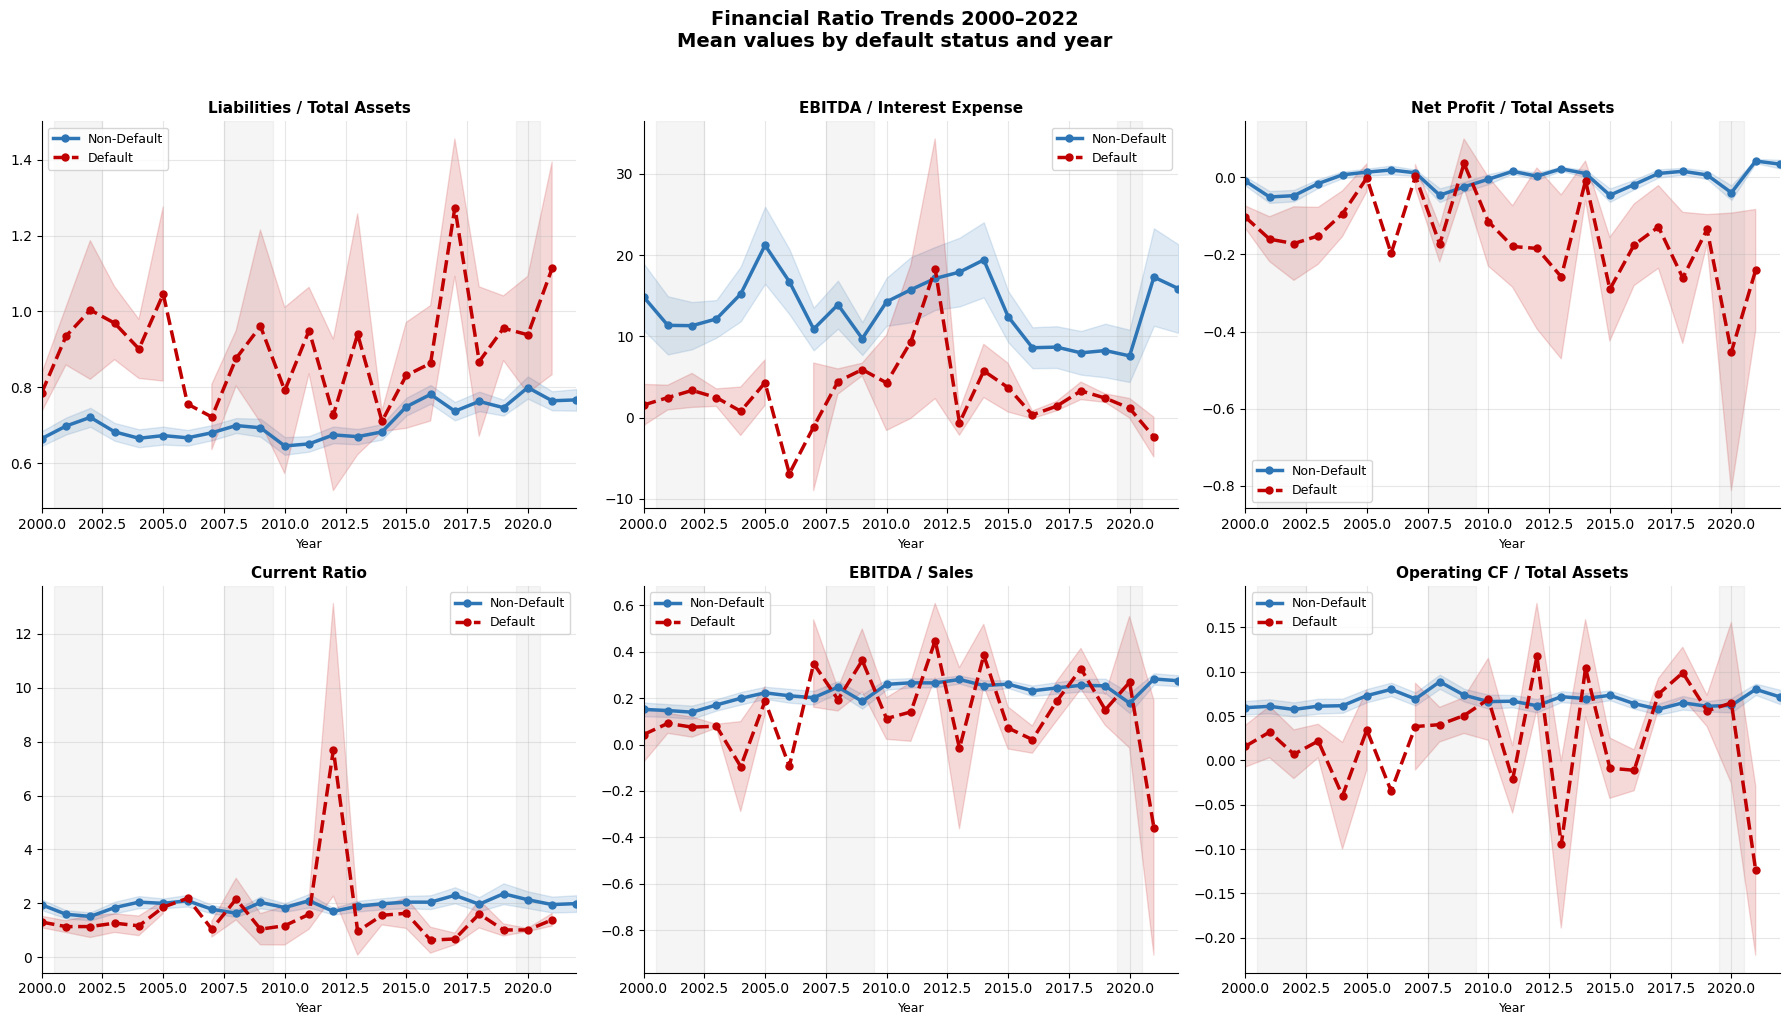

Saved: eda_05_trends.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Financial Ratio Trends 2000–2022\nMean values by default status and year',
             fontsize=14, fontweight='bold', y=1.02)

trend_vars = [
    ('LIABTA',   'Liabilities / Total Assets'),
    ('EBITDAFE', 'EBITDA / Interest Expense'),
    ('NITA',     'Net Profit / Total Assets'),
    ('CR',       'Current Ratio'),
    ('EBITDASA', 'EBITDA / Sales'),
    ('CFTA',     'Operating CF / Total Assets'),
]

for ax, (var, title) in zip(axes, trend_vars):
    for val, label, col, ls in [(0,'Non-Default',C_NODEF,'-'),(1,'Default',C_DEF,'--')]:
        grp = p[p.y_default==val].groupby('Year')[var].agg(['mean','sem'])
        if len(grp) > 2:
            ax.plot(grp.index, grp['mean'], color=col, lw=2.5, ls=ls,
                    marker='o', ms=5, label=label)
            ax.fill_between(grp.index,
                             grp['mean'] - grp['sem'],
                             grp['mean'] + grp['sem'],
                             alpha=0.15, color=col)

    # Shade recession years
    for yr_s, yr_e in [(2001,2002),(2008,2009),(2020,2020)]:
        ax.axvspan(yr_s-0.5, yr_e+0.5, alpha=0.08, color='grey')

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Year', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_xlim([2000, 2022])

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_05_trends.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_05_trends.png")

## EDA 7 — Missing Data Analysis

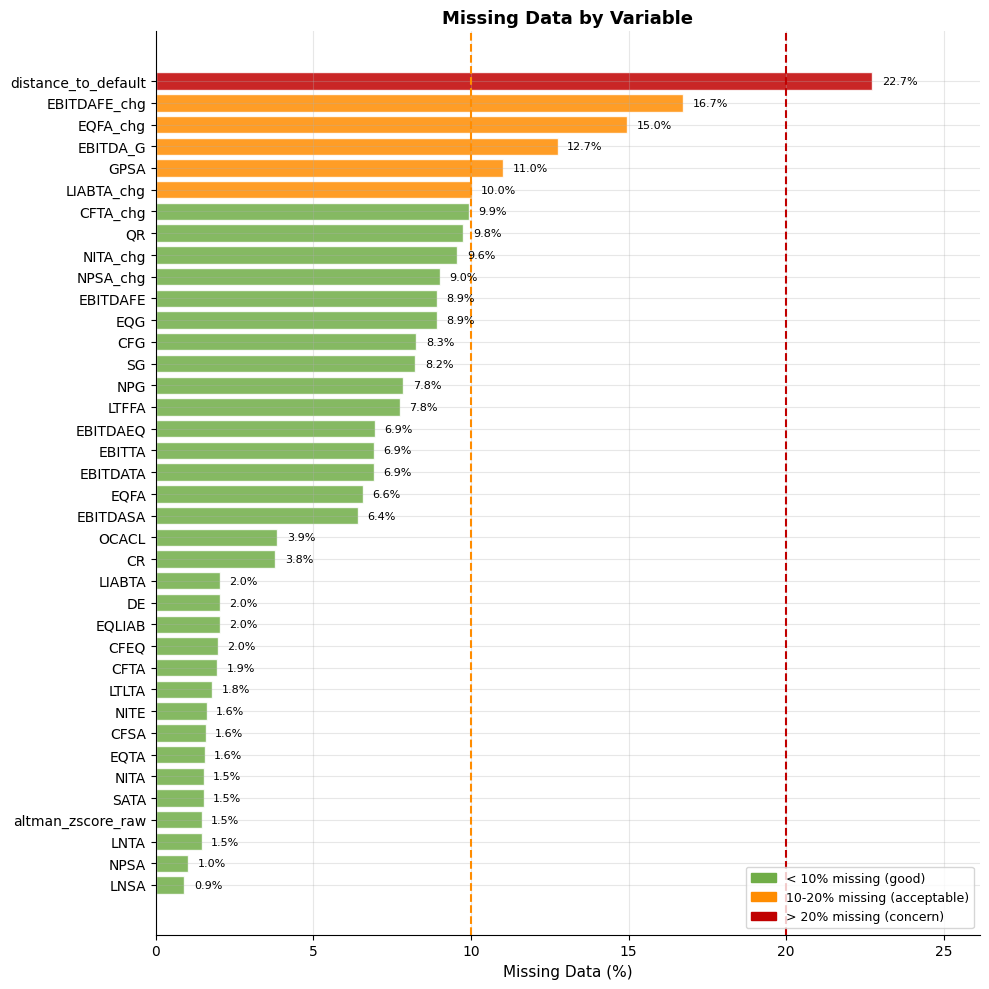

Saved: eda_06_missing_data.png


In [ ]:
miss_pct = p[RATIO_VARS + ['distance_to_default','altman_zscore_raw']].isna().mean()*100
miss_pct = miss_pct.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors  = [C_DEF if v>20 else C_WARN if v>10 else C_NEUT for v in miss_pct.values]
bars    = ax.barh(miss_pct.index, miss_pct.values, color=colors, alpha=0.85, edgecolor='white')

ax.axvline(10, color=C_WARN, ls='--', lw=1.5, label='10% threshold')
ax.axvline(20, color=C_DEF,  ls='--', lw=1.5, label='20% threshold')

for bar, val in zip(bars, miss_pct.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Missing Data (%)', fontsize=11)
ax.set_title('Missing Data by Variable', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, max(miss_pct.values)*1.15])

patches = [mpatches.Patch(color=C_NEUT, label='< 10% missing (good)'),
           mpatches.Patch(color=C_WARN, label='10-20% missing (acceptable)'),
           mpatches.Patch(color=C_DEF,  label='> 20% missing (concern)')]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_06_missing_data.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_06_missing_data.png")

## EDA 8 — Change Variable Analysis (Financial Deterioration Trajectories)

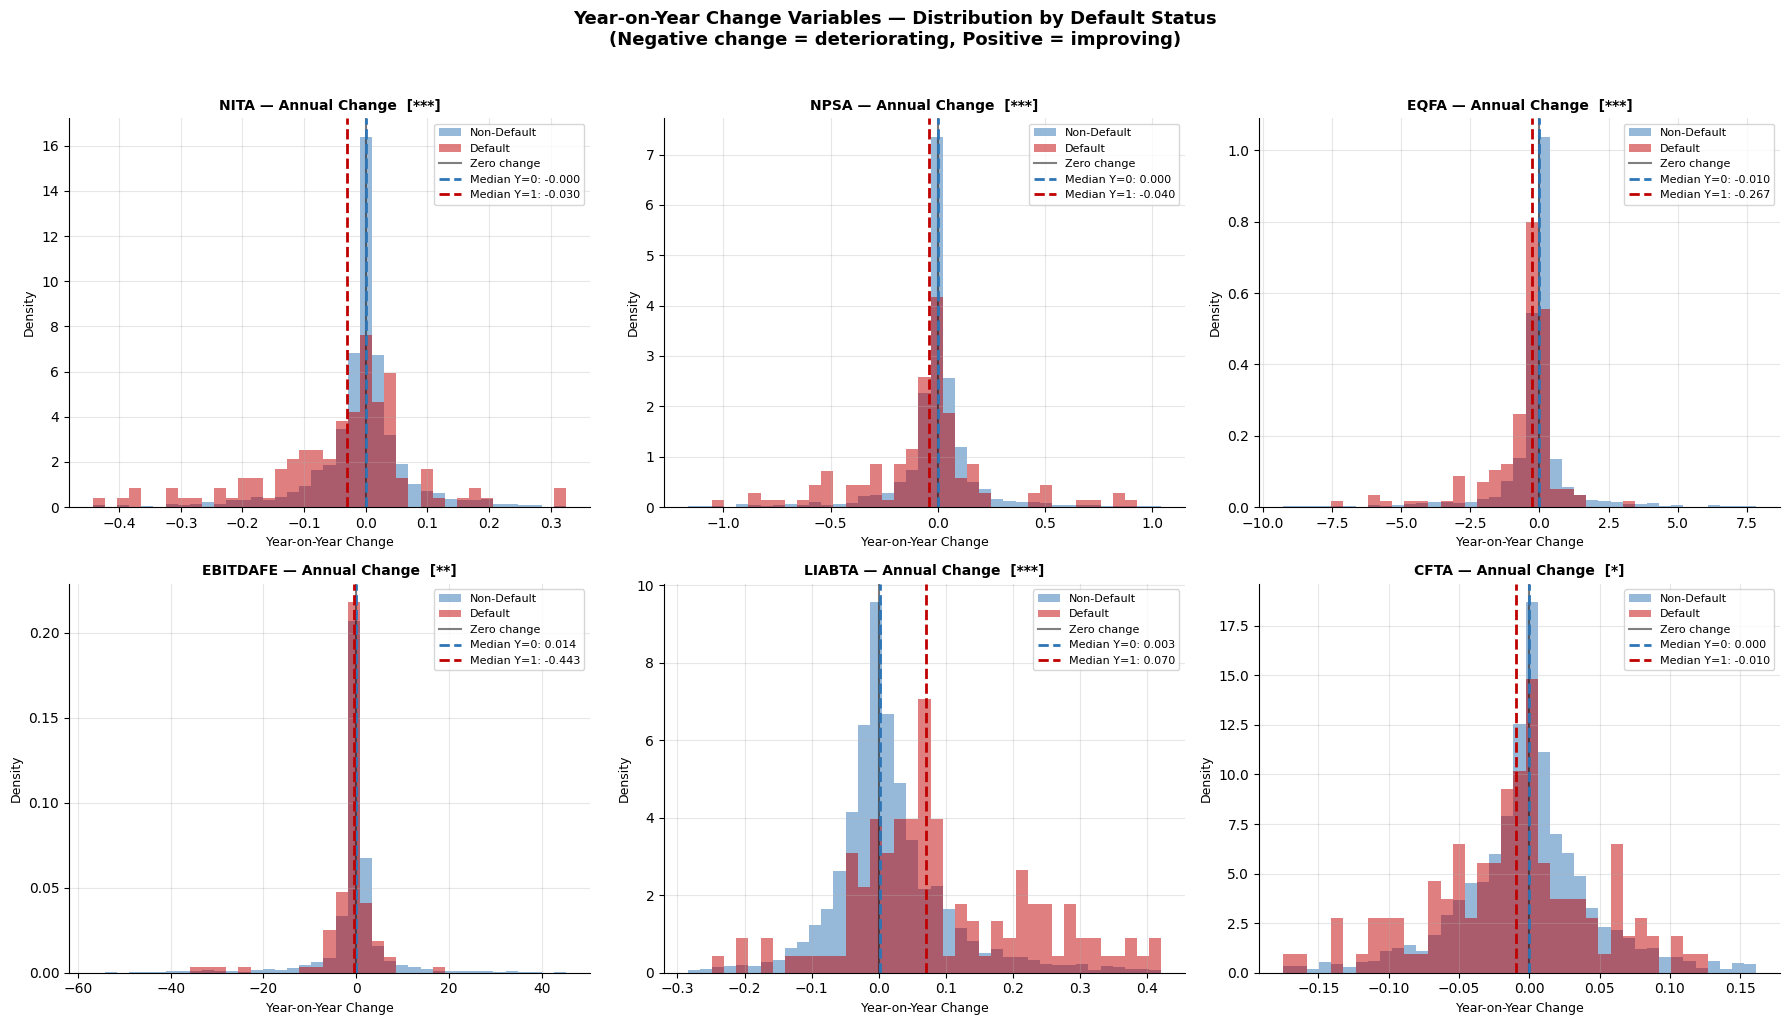

Saved: eda_07_change_vars.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Year-on-Year Change Variables — Distribution by Default Status\n'
             '(Negative change = deteriorating, Positive = improving)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, var in zip(axes, CHANGE_VARS):
    chg_col = f'{var}_chg'
    if chg_col not in p.columns: continue
    d0 = p[p.y_default==0][chg_col].dropna()
    d1 = p[p.y_default==1][chg_col].dropna()

    bins = np.linspace(p[chg_col].quantile(0.02), p[chg_col].quantile(0.98), 40)
    ax.hist(d0, bins=bins, alpha=0.5, color=C_NODEF, density=True, label='Non-Default')
    ax.hist(d1, bins=bins, alpha=0.5, color=C_DEF,   density=True, label='Default')
    ax.axvline(0, color='black', lw=1.5, ls='-', alpha=0.5, label='Zero change')
    ax.axvline(d0.median(), color=C_NODEF, lw=2, ls='--', label=f'Median Y=0: {d0.median():.3f}')
    ax.axvline(d1.median(), color=C_DEF,   lw=2, ls='--', label=f'Median Y=1: {d1.median():.3f}')

    if len(d0)>5 and len(d1)>5:
        _, pv = mannwhitneyu(d0, d1, alternative='two-sided')
        sig = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        ax.set_title(f'{var} — Annual Change  [{sig}]', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Year-on-Year Change', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_07_change_vars.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_07_change_vars.png")

## EDA 9 — Altman Z-Score Zone Analysis

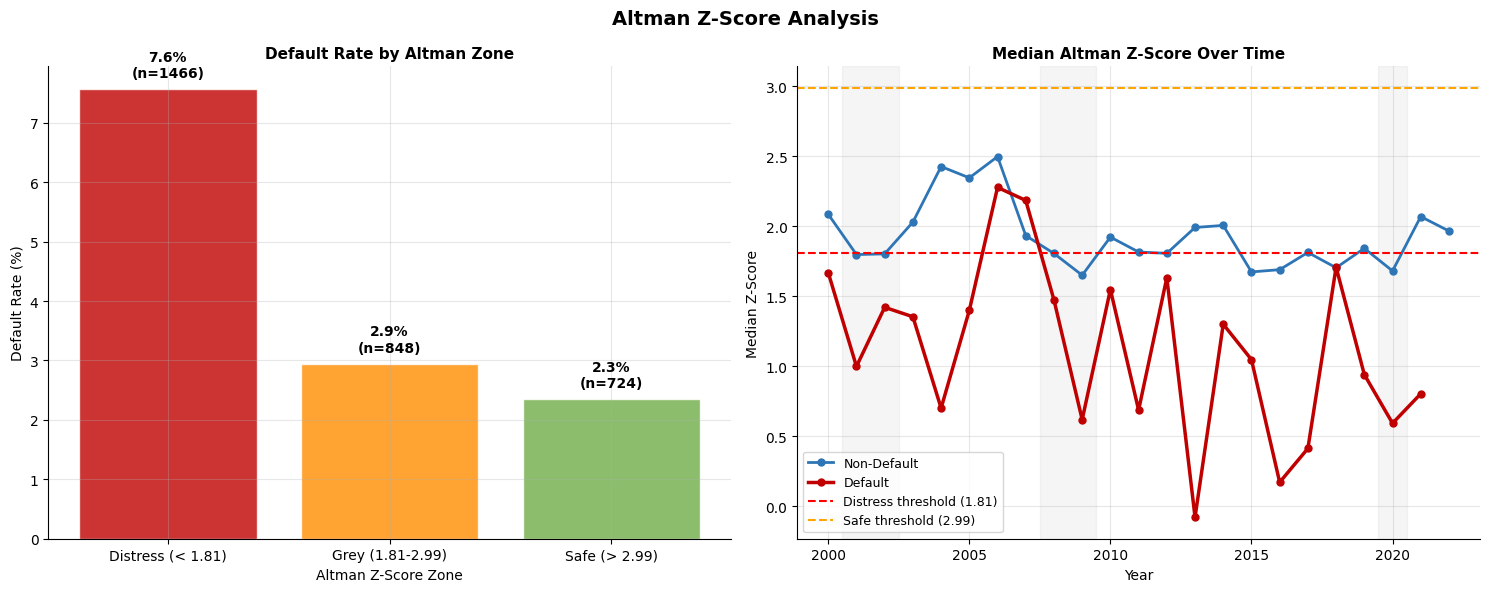

Saved: eda_08_altman.png


In [ ]:
p['altman_zone'] = pd.cut(p['altman_zscore_raw'],
                           bins=[-np.inf, 1.81, 2.99, np.inf],
                           labels=['Distress (< 1.81)','Grey (1.81-2.99)','Safe (> 2.99)'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Altman Z-Score Analysis", fontsize=14, fontweight='bold')

# Left: Default rate by Altman zone
ax = axes[0]
zone_def = p.groupby('altman_zone', observed=True)['y_default'].agg(['mean','sum','count'])
zone_def['rate'] = zone_def['mean']*100
colors_z = [C_DEF, C_WARN, C_NEUT]
bars = ax.bar(zone_def.index, zone_def['rate'], color=colors_z, alpha=0.8, edgecolor='white')
for bar, (idx, row) in zip(bars, zone_def.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{row['rate']:.1f}%\n(n={row['count']:.0f})",
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Default Rate by Altman Zone', fontweight='bold', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=10)
ax.set_xlabel('Altman Z-Score Zone', fontsize=10)

# Right: Z-score distribution over time for defaulted vs non-defaulted
ax = axes[1]
for val, label, col, lw in [(0,'Non-Default',C_NODEF,2),(1,'Default',C_DEF,2.5)]:
    trend = p[p.y_default==val].groupby('Year')['altman_zscore_raw'].median()
    ax.plot(trend.index, trend.values, color=col, lw=lw, marker='o', ms=5, label=label)
ax.axhline(1.81, color='red',    ls='--', lw=1.5, label='Distress threshold (1.81)')
ax.axhline(2.99, color='orange', ls='--', lw=1.5, label='Safe threshold (2.99)')
for yr_s, yr_e in [(2001,2002),(2008,2009),(2020,2020)]:
    ax.axvspan(yr_s-0.5, yr_e+0.5, alpha=0.08, color='grey')
ax.set_title('Median Altman Z-Score Over Time', fontweight='bold', fontsize=11)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Median Z-Score', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/eda_08_altman.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: eda_08_altman.png")

---
# SECTION C — FEATURE ENGINEERING & MODELLING PREPARATION

## Step 9 — Pull FRED Macro Data

In [ ]:
print("="*55)
print("STEP 9: FRED MACRO DATA")
print("="*55)

MACRO_COLS = ['gdp_growth','fed_funds_rate','treasury_10yr','treasury_2yr',
              'hy_spread','vix','inflation_rate','unemployment','nfci','yield_curve_slope']

if FRED_API_KEY == 'PASTE_YOUR_FRED_API_KEY_HERE':
    print("SKIPPED — paste your FRED key in Cell 3.")
    print("Get free key at: https://fred.stlouisfed.org/docs/api/api_key.html")
    for col in MACRO_COLS:
        p[col] = np.nan
else:
    from fredapi import Fred
    fred = Fred(api_key=FRED_API_KEY)
    SERIES = {
        'gdp_growth':     'A191RL1A225NBEA',
        'fed_funds_rate': 'FEDFUNDS',
        'treasury_10yr':  'GS10',
        'treasury_2yr':   'GS2',
        'hy_spread':      'BAMLH0A0HYM2',
        'vix':            'VIXCLS',
        'cpi':            'CPIAUCSL',
        'unemployment':   'UNRATE',
        'nfci':           'NFCI',
    }
    macro = {}
    for name, sid in SERIES.items():
        try:
            s = fred.get_series(sid,
                observation_start='2000-01-01',
                observation_end='2022-12-31')
            s.index = pd.to_datetime(s.index)
            annual  = s.resample('YE').mean()
            annual.index = annual.index.year
            macro[name] = annual
            print(f"  OK  {name}")
        except Exception as e:
            print(f"  ERR {name}: {e}")
    macro_df = pd.DataFrame(macro).reset_index().rename(columns={'index':'Year'})
    macro_df = macro_df[(macro_df.Year>=2000)&(macro_df.Year<=2022)]
    if 'treasury_10yr' in macro_df and 'treasury_2yr' in macro_df:
        macro_df['yield_curve_slope'] = macro_df['treasury_10yr'] - macro_df['treasury_2yr']
    if 'cpi' in macro_df.columns:
        macro_df['inflation_rate'] = macro_df['cpi'].pct_change()*100
        macro_df = macro_df.drop(columns=['cpi'])
    macro_df.to_csv(f'{DATA}/macro_panel.csv', index=False)
    p = p.merge(macro_df, on='Year', how='left')
    print(f"Macro data merged.")

p.to_csv(f'{DATA}/panel_cleaned.csv', index=False)
print(f"Cleaned panel saved: {DATA}/panel_cleaned.csv")

STEP 9: FRED MACRO DATA
  OK  gdp_growth
  OK  fed_funds_rate
  OK  treasury_10yr
  OK  treasury_2yr
  OK  hy_spread
  OK  vix
  OK  cpi
  OK  unemployment
  OK  nfci
Macro data merged.
Cleaned panel saved: /content/drive/MyDrive/DBA/Research/data/panel_cleaned.csv


## Step 10 — Time-Based Train/Test Split

In [ ]:
print("="*55)
print("STEP 10: TRAIN/TEST SPLIT")
print("="*55)

train = p[p['Year'] <= TRAIN_END].copy()
test  = p[p['Year'] >= TEST_START].copy()

print(f"Train (2000-{TRAIN_END}): {len(train):,} rows | {train.y_default.sum()} defaults ({train.y_default.mean()*100:.2f}%)")
print(f"Test  ({TEST_START}-2022): {len(test):,}  rows | {test.y_default.sum()} defaults ({test.y_default.mean()*100:.2f}%)")

STEP 10: TRAIN/TEST SPLIT
Train (2000-2017): 2,609 rows | 123 defaults (4.71%)
Test  (2018-2022): 474  rows | 31 defaults (6.54%)


## Step 11 — Define Feature Sets

In [ ]:
print("="*55)
print("STEP 11: FEATURE SETS")
print("="*55)

BASE_FEATURES = [
    'EBITDAFE','EBITDATA','EBITDAEQ','EBITDASA','NPSA','GPSA','NITA','NITE','EBITTA',
    'EQTA','EQFA','EQLIAB','LIABTA','LTLTA','LTFFA','DE',
    'CFEQ','CFTA','CFSA','OCACL','CR','QR','LNTA','LNSA','SATA',
    'SG','EBITDA_G','CFG','EQG','NPG'
] + CHANGE_FEATURES

FEAT_WITH_DD    = BASE_FEATURES + ['distance_to_default']
MACRO_FEAT      = ['gdp_growth','fed_funds_rate','yield_curve_slope',
                   'hy_spread','vix','unemployment','nfci','inflation_rate']
FEAT_WITH_MACRO = FEAT_WITH_DD + MACRO_FEAT

def filter_coverage(features, df, threshold=0.30):
    return [f for f in features
            if f in df.columns and df[f].notna().mean() >= threshold]

FEAT_SET1 = filter_coverage(BASE_FEATURES,  train)
FEAT_SET2 = filter_coverage(FEAT_WITH_DD,   train)
FEAT_SET3 = filter_coverage(FEAT_WITH_MACRO,train)

print(f"Set 1 — Accounting + Change vars:     {len(FEAT_SET1)} features")
print(f"Set 2 — + Distance to Default:        {len(FEAT_SET2)} features")
print(f"Set 3 — + Macroeconomic variables:    {len(FEAT_SET3)} features")
print(f"DD in Set 2: {'distance_to_default' in FEAT_SET2}")
print(f"\nChange features in Set 1:")
for f in CHANGE_FEATURES:
    if f in FEAT_SET1:
        print(f"  {f}: {train[f].notna().mean()*100:.1f}% coverage")

STEP 11: FEATURE SETS
Set 1 — Accounting + Change vars:     36 features
Set 2 — + Distance to Default:        37 features
Set 3 — + Macroeconomic variables:    44 features
DD in Set 2: True

Change features in Set 1:
  NITA_chg: 88.7% coverage
  NPSA_chg: 89.4% coverage
  EQFA_chg: 83.4% coverage
  EBITDAFE_chg: 81.4% coverage
  LIABTA_chg: 88.2% coverage
  CFTA_chg: 88.3% coverage


## Step 12 — Model Infrastructure (SMOTE inside CV folds)

In [ ]:
print("="*55)
print("STEP 12: MODEL INFRASTRUCTURE")
print("="*55)

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.metrics          import (roc_auc_score, f1_score, precision_score,
                                      recall_score, brier_score_loss,
                                      classification_report, roc_curve)
from imblearn.pipeline        import Pipeline as ImbPipeline
from imblearn.over_sampling   import SMOTE
import xgboost as xgb
import lightgbm as lgb

def make_models(scale_pos):
    k = max(1, min(5, int(scale_pos)-1)) if scale_pos>1 else 1
    return {
        'Logistic Regression': ImbPipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=42,k_neighbors=k)),
            ('model',  LogisticRegression(max_iter=1000,random_state=42,C=0.1))
        ]),
        'Random Forest': ImbPipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=42,k_neighbors=k)),
            ('model',  RandomForestClassifier(n_estimators=200,random_state=42,
                                               class_weight='balanced',max_depth=5))
        ]),
        'XGBoost': ImbPipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=42,k_neighbors=k)),
            ('model',  xgb.XGBClassifier(n_estimators=200,random_state=42,
                                           scale_pos_weight=scale_pos,
                                           max_depth=4,learning_rate=0.05,
                                           eval_metric='logloss',verbosity=0))
        ]),
        'LightGBM': ImbPipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=42,k_neighbors=k)),
            ('model',  lgb.LGBMClassifier(n_estimators=200,random_state=42,
                                            scale_pos_weight=scale_pos,
                                            max_depth=4,learning_rate=0.05,
                                            verbosity=-1))
        ]),
    }

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'AUC':       round(roc_auc_score(y_true, y_prob),4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0),4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0),4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0),4),
        'Brier':     round(brier_score_loss(y_true, y_prob),4),
    }

def run_model_set(feat_cols, set_name, train_df, test_df):
    print(f"\n--- {set_name} ({len(feat_cols)} features) ---")
    X_tr=train_df[feat_cols]; y_tr=train_df['y_default'].astype(int)
    X_te=test_df[feat_cols];  y_te=test_df['y_default'].astype(int)
    mask_tr=y_tr.notna(); X_tr=X_tr[mask_tr]; y_tr=y_tr[mask_tr].astype(int)
    mask_te=y_te.notna(); X_te=X_te[mask_te]; y_te=y_te[mask_te].astype(int)
    sp = max(1,(y_tr==0).sum()/max(1,(y_tr==1).sum()))
    models=make_models(sp); cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    results={}; fitted={}
    print(f"  {'Model':<22} {'CV-AUC':>7} {'Test-AUC':>9} {'F1':>7} {'Prec':>8} {'Recall':>8} {'Brier':>7}")
    print(f"  {'-'*75}")
    for name, pipe in models.items():
        cv_auc = cross_validate(pipe,X_tr,y_tr,cv=cv,scoring='roc_auc')['test_score'].mean()
        pipe.fit(X_tr,y_tr); fitted[name]=pipe
        y_prob=pipe.predict_proba(X_te)[:,1]; y_pred=pipe.predict(X_te)
        m=compute_metrics(y_te,y_pred,y_prob); results[name]={'CV_AUC':round(cv_auc,4),**m}
        print(f"  {name:<22} {cv_auc:>7.4f} {m['AUC']:>9.4f} {m['F1']:>7.4f} "
              f"{m['Precision']:>8.4f} {m['Recall']:>8.4f} {m['Brier']:>7.4f}")
    # Altman baseline
    z_raw=test_df.loc[mask_te,'altman_zscore_raw'].fillna(test_df['altman_zscore_raw'].median())
    z_pred=(z_raw<1.81).astype(int); z_prob=1/(1+np.exp(z_raw.values))
    z_auc=roc_auc_score(y_te,-z_raw); z_m=compute_metrics(y_te,z_pred,z_prob)
    results['Altman Z-Score']={'CV_AUC':None,'AUC':z_auc,**z_m}
    print(f"  {'Altman Z-Score':<22} {'N/A':>7} {z_auc:>9.4f} {z_m['F1']:>7.4f} "
          f"{z_m['Precision']:>8.4f} {z_m['Recall']:>8.4f} {z_m['Brier']:>7.4f}")
    print(f"  {'-'*75}")
    return results, fitted, y_te, X_te

print("Model infrastructure ready. SMOTE inside each CV fold.")

STEP 12: MODEL INFRASTRUCTURE
Model infrastructure ready. SMOTE inside each CV fold.


## Step 13 — Run All Three Model Sets

In [ ]:
print("="*55)
print("STEP 13: RUNNING ALL MODEL SETS")
print("="*55)

results_set1,models_set1,y_te1,X_te1 = run_model_set(FEAT_SET1,"SET 1 — Accounting + Change",train,test)
results_set2,models_set2,y_te2,X_te2 = run_model_set(FEAT_SET2,"SET 2 — + Distance to Default",train,test)
results_set3,models_set3,y_te3,X_te3 = run_model_set(FEAT_SET3,"SET 3 — + Macroeconomic",train,test)

rows=[]
for sn,res in {'Set1_Accounting':results_set1,'Set2_DD':results_set2,'Set3_Macro':results_set3}.items():
    for model,metrics in res.items():
        rows.append({'Set':sn,'Model':model,**metrics})
results_df=pd.DataFrame(rows)
results_df.to_csv(f'{OUTPUT}/model_results_all.csv',index=False)
print(f"\nResults saved: {OUTPUT}/model_results_all.csv")

STEP 13: RUNNING ALL MODEL SETS

--- SET 1 — Accounting + Change (36 features) ---
  Model                   CV-AUC  Test-AUC      F1     Prec   Recall   Brier
  ---------------------------------------------------------------------------
  Logistic Regression     0.7162    0.8260  0.3226   0.2151   0.6452  0.1598
  Random Forest           0.7570    0.7867  0.3590   0.2442   0.6774  0.1370
  XGBoost                 0.7058    0.7747  0.2595   0.1558   0.7742  0.2087
  LightGBM                0.6954    0.7770  0.2300   0.1361   0.7419  0.2319
  Altman Z-Score             N/A    0.7840  0.2143   0.1205   0.9677  0.0750
  ---------------------------------------------------------------------------

--- SET 2 — + Distance to Default (37 features) ---
  Model                   CV-AUC  Test-AUC      F1     Prec   Recall   Brier
  ---------------------------------------------------------------------------
  Logistic Regression     0.7330    0.8123  0.2635   0.1618   0.7097  0.1770
  Random Fores

## Step 14 — Hypothesis Testing (DeLong Test)

In [ ]:
print("="*55)
print("STEP 14: DELONG HYPOTHESIS TESTS")
print("="*55)

def delong_test(y_true, p1, p2):
    def auc_var(y,p):
        pos=p[y==1]; neg=p[y==0]; m,n=len(pos),len(neg)
        if m==0 or n==0: return 0,0
        V10=np.array([np.mean(pi>neg)+0.5*np.mean(pi==neg) for pi in pos])
        V01=np.array([np.mean(pj<pos)+0.5*np.mean(pj==pos) for pj in neg])
        return np.mean(V10), np.var(V10,ddof=1)/m+np.var(V01,ddof=1)/n
    a1,v1=auc_var(y_true,p1); a2,v2=auc_var(y_true,p2)
    vd=v1+v2
    if vd<=0: return a1,a2,0,1.0
    z=(a1-a2)/np.sqrt(vd)
    return a1,a2,z,2*(1-stats.norm.cdf(abs(z)))

ML_MODELS=['Random Forest','XGBoost','LightGBM']
hyp_rows=[]

print("\n── RQ1: ML Ensemble vs Traditional Models ──")
print(f"H1₀: ML models do not achieve significantly higher AUC than baselines")
print()
print(f"  {'Comparison':<42} {'AUC_ML':>8} {'AUC_BL':>8} {'z':>7} {'p':>9} {'Sig':>5}  Decision")
print(f"  {'-'*93}")
for ml in ML_MODELS:
    for bl,bl_pipe in [('Logistic Regression',models_set1.get('Logistic Regression')),
                        ('Altman Z-Score',None)]:
        p_ml=models_set1[ml].predict_proba(X_te1)[:,1]
        if bl=='Altman Z-Score':
            z_raw=test.loc[y_te1.index,'altman_zscore_raw'].fillna(test['altman_zscore_raw'].median())
            a_ml,a_bl,z,pv=delong_test(y_te1.values,p_ml,-z_raw.values)
        else:
            p_bl=bl_pipe.predict_proba(X_te1)[:,1]
            a_ml,a_bl,z,pv=delong_test(y_te1.values,p_ml,p_bl)
        sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        dec='Reject H1₀' if pv<0.05 else 'Fail to Reject H1₀'
        label=f"{ml} vs {bl}"
        print(f"  {label:<42} {a_ml:>8.4f} {a_bl:>8.4f} {z:>7.3f} {pv:>9.4f} {sig:>5}  {dec}")
        hyp_rows.append({'RQ':'RQ1','Comparison':label,'AUC_model':a_ml,'AUC_baseline':a_bl,
                          'z':z,'p_value':pv,'Sig':sig,'Decision':dec})

print("\n── RQ2: With DD vs Without DD ──")
print(f"H2₀: Including DD does not significantly improve AUC")
print()
print(f"  {'Model':<25} {'AUC_with_DD':>12} {'AUC_without':>12} {'z':>7} {'p':>9} {'Sig':>5}  Decision")
print(f"  {'-'*80}")
for ml in ML_MODELS:
    if ml not in models_set2: continue
    p_with=models_set2[ml].predict_proba(X_te2)[:,1]
    p_wo  =models_set1[ml].predict_proba(X_te2[FEAT_SET1])[:,1]
    a_w,a_wo,z,pv=delong_test(y_te2.values,p_with,p_wo)
    sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
    dec='Reject H2₀' if pv<0.05 else 'Fail to Reject H2₀'
    print(f"  {ml:<25} {a_w:>12.4f} {a_wo:>12.4f} {z:>7.3f} {pv:>9.4f} {sig:>5}  {dec}")
    hyp_rows.append({'RQ':'RQ2','Comparison':ml,'AUC_model':a_w,'AUC_baseline':a_wo,
                      'z':z,'p_value':pv,'Sig':sig,'Decision':dec})

print("\n── RQ3: With Macro vs Without Macro ──")
print(f"H3₀: Including macro variables does not significantly improve AUC")
print()
print(f"  {'Model':<25} {'AUC_with_Macro':>15} {'AUC_without':>12} {'z':>7} {'p':>9} {'Sig':>5}  Decision")
print(f"  {'-'*85}")
for ml in ML_MODELS:
    if ml not in models_set3: continue
    p_with=models_set3[ml].predict_proba(X_te3)[:,1]
    p_wo  =models_set2[ml].predict_proba(X_te3[FEAT_SET2])[:,1]
    a_w,a_wo,z,pv=delong_test(y_te3.values,p_with,p_wo)
    sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
    dec='Reject H3₀' if pv<0.05 else 'Fail to Reject H3₀'
    print(f"  {ml:<25} {a_w:>15.4f} {a_wo:>12.4f} {z:>7.3f} {pv:>9.4f} {sig:>5}  {dec}")
    hyp_rows.append({'RQ':'RQ3','Comparison':ml,'AUC_model':a_w,'AUC_baseline':a_wo,
                      'z':z,'p_value':pv,'Sig':sig,'Decision':dec})

pd.DataFrame(hyp_rows).to_csv(f'{OUTPUT}/hypothesis_tests.csv',index=False)
print(f"\nSaved: {OUTPUT}/hypothesis_tests.csv")
print("* p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant")

STEP 14: DELONG HYPOTHESIS TESTS

── RQ1: ML Ensemble vs Traditional Models ──
H1₀: ML models do not achieve significantly higher AUC than baselines

  Comparison                                   AUC_ML   AUC_BL       z         p   Sig  Decision
  ---------------------------------------------------------------------------------------------
  Random Forest vs Logistic Regression         0.7867   0.8260  -0.569    0.5690  n.s.  Fail to Reject H1₀
  Random Forest vs Altman Z-Score              0.7867   0.7840   0.044    0.9651  n.s.  Fail to Reject H1₀
  XGBoost vs Logistic Regression               0.7747   0.8260  -0.721    0.4707  n.s.  Fail to Reject H1₀
  XGBoost vs Altman Z-Score                    0.7747   0.7840  -0.141    0.8880  n.s.  Fail to Reject H1₀
  LightGBM vs Logistic Regression              0.7770   0.8260  -0.711    0.4773  n.s.  Fail to Reject H1₀
  LightGBM vs Altman Z-Score                   0.7770   0.7840  -0.110    0.9121  n.s.  Fail to Reject H1₀

── RQ2: With D

## Model Results — Visualizations

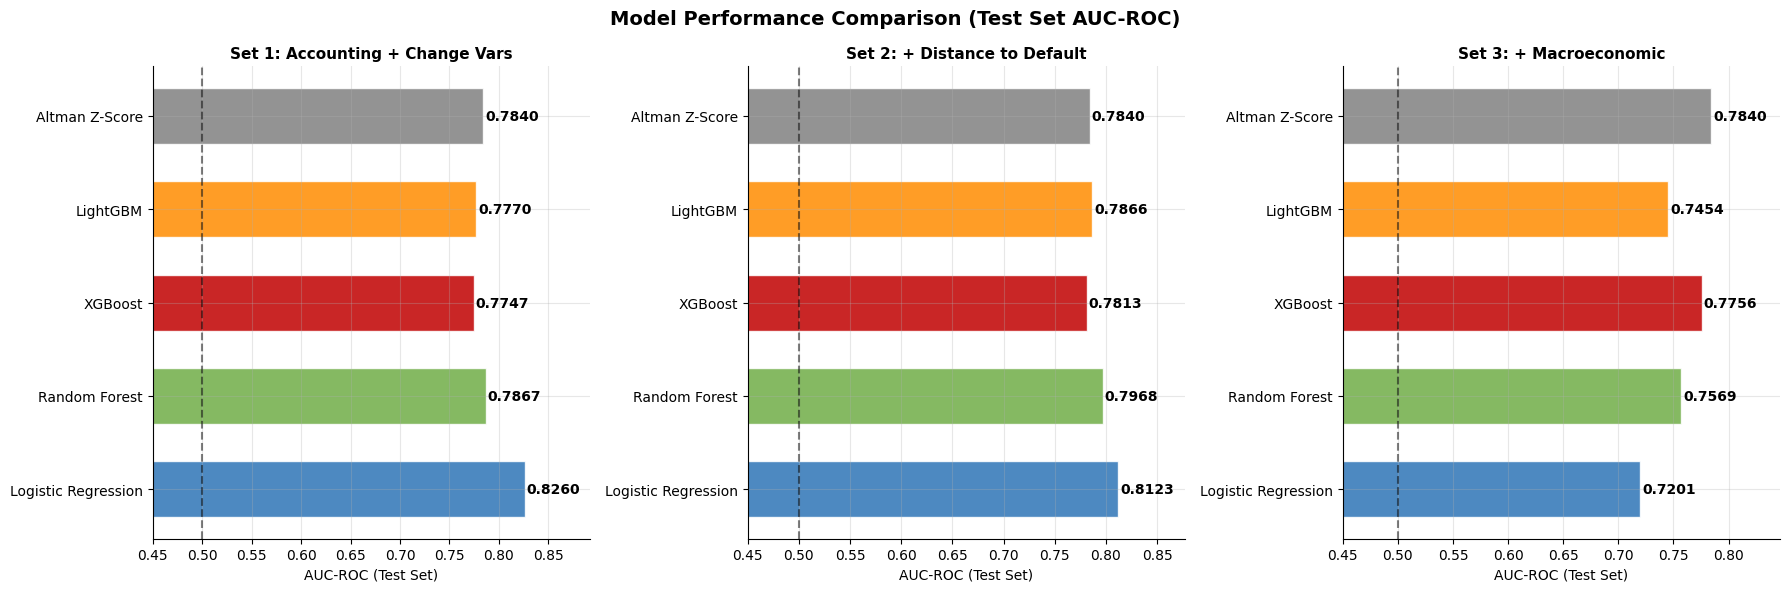

Saved: model_01_auc_comparison.png


In [ ]:
# ── Figure: AUC comparison across all sets and models ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison (Test Set AUC-ROC)',
             fontsize=14, fontweight='bold')

model_colors = {
    'Logistic Regression': '#2E75B6',
    'Random Forest':       '#70AD47',
    'XGBoost':             '#C00000',
    'LightGBM':            '#FF8C00',
    'Altman Z-Score':      '#808080',
}
set_configs = [
    (results_set1,'Set 1: Accounting + Change Vars'),
    (results_set2,'Set 2: + Distance to Default'),
    (results_set3,'Set 3: + Macroeconomic'),
]
for ax,(res,title) in zip(axes,set_configs):
    models_list = list(res.keys())
    aucs        = [res[m]['AUC'] for m in models_list]
    colors      = [model_colors.get(m,'grey') for m in models_list]
    bars = ax.barh(models_list, aucs, color=colors, alpha=0.85, edgecolor='white', height=0.6)
    for bar, auc in zip(bars, aucs):
        ax.text(auc+0.002, bar.get_y()+bar.get_height()/2,
                f'{auc:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.axvline(0.5, color='black', ls='--', lw=1.5, alpha=0.5, label='Random (0.5)')
    ax.set_xlim([0.45, max(aucs)*1.08])
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('AUC-ROC (Test Set)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/model_01_auc_comparison.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Saved: model_01_auc_comparison.png")

## ROC Curves — All Three Model Sets

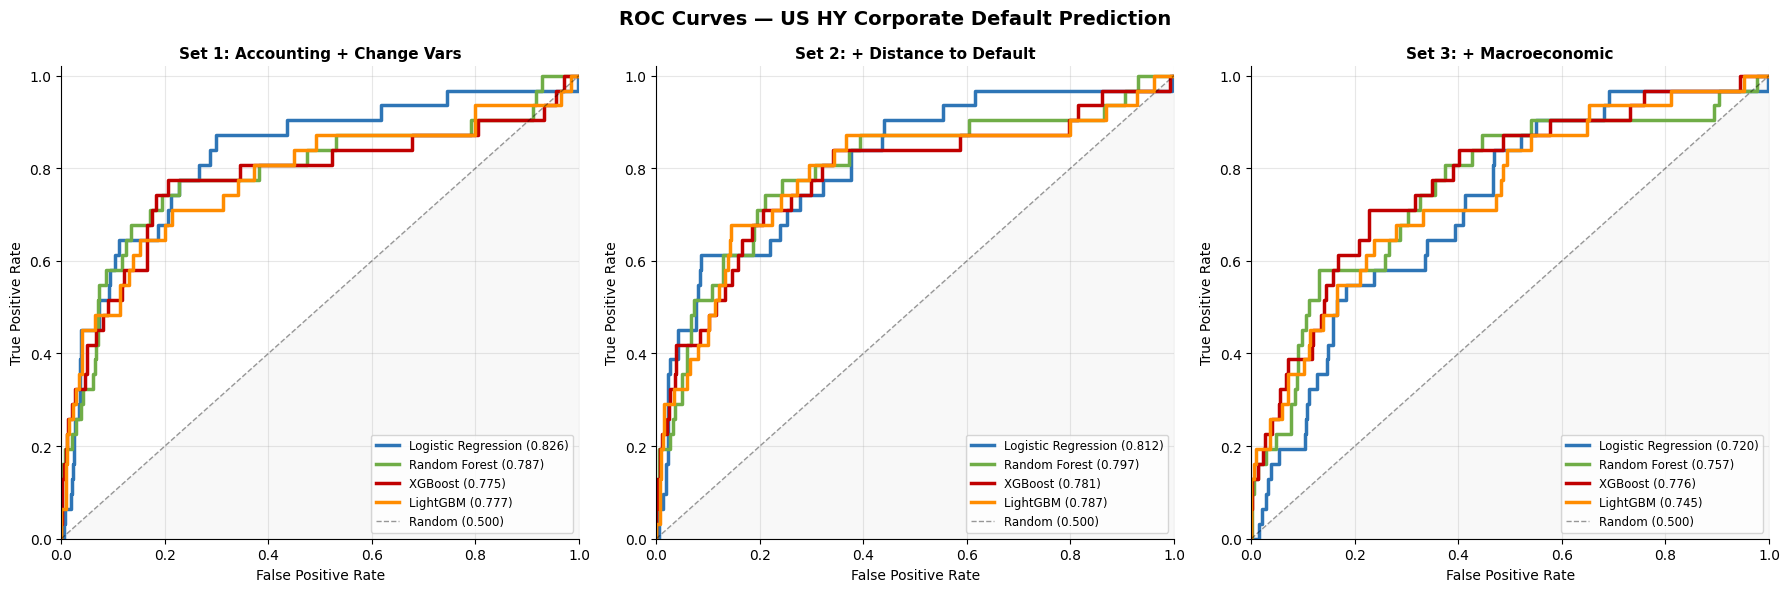

Saved: model_02_roc_curves.png


In [ ]:
fig, axes = plt.subplots(1,3,figsize=(18,6))
line_cols = ['#2E75B6','#70AD47','#C00000','#FF8C00','#808080']
set_cfgs  = [
    (models_set1,X_te1,y_te1,'Set 1: Accounting + Change Vars'),
    (models_set2,X_te2,y_te2,'Set 2: + Distance to Default'),
    (models_set3,X_te3,y_te3,'Set 3: + Macroeconomic'),
]
for ax,(mods,X_te,y_te,title) in zip(axes,set_cfgs):
    for (name,pipe),col in zip(mods.items(),line_cols):
        probs     = pipe.predict_proba(X_te)[:,1]
        fpr,tpr,_ = roc_curve(y_te.values,probs)
        auc       = roc_auc_score(y_te.values,probs)
        ax.plot(fpr,tpr,color=col,lw=2.5,label=f'{name} ({auc:.3f})')
    ax.fill_between([0,1],[0,1],alpha=0.05,color='grey')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random (0.500)')
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('False Positive Rate',fontsize=10)
    ax.set_ylabel('True Positive Rate',fontsize=10)
    ax.legend(fontsize=8.5,loc='lower right')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

fig.suptitle('ROC Curves — US HY Corporate Default Prediction',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/model_02_roc_curves.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Saved: model_02_roc_curves.png")

## Metrics Comparison Heatmap

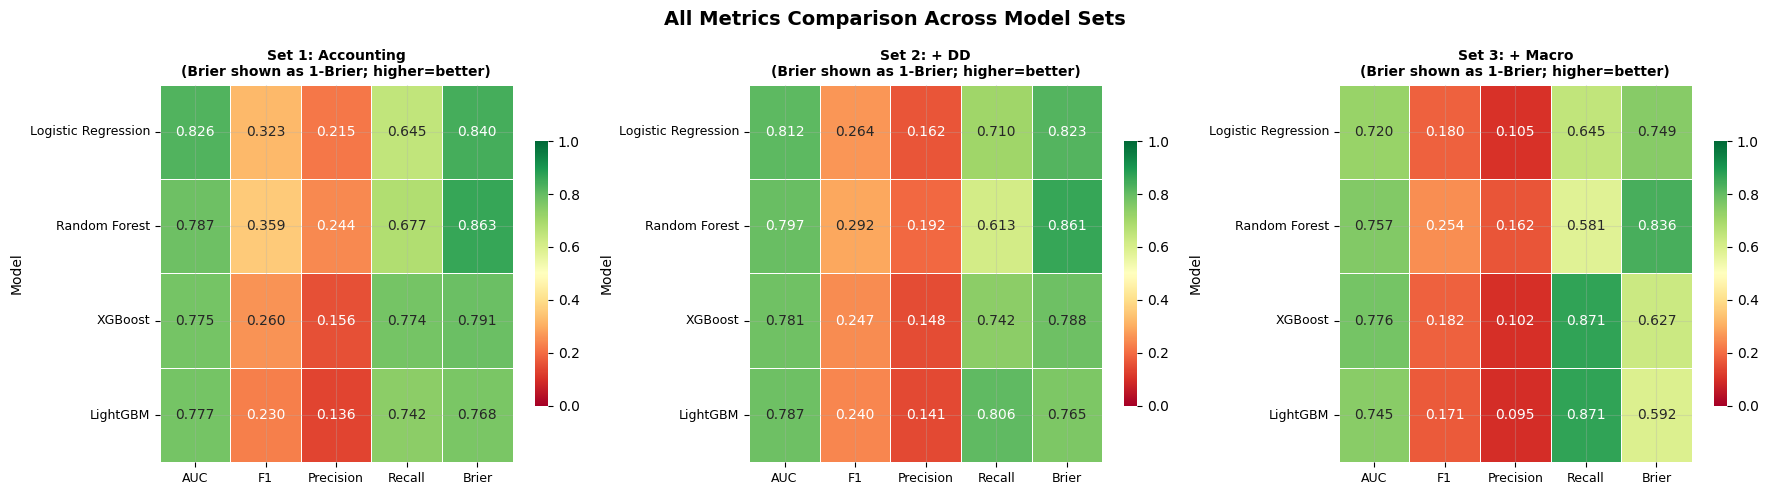

Saved: model_03_metrics_heatmap.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('All Metrics Comparison Across Model Sets',
             fontsize=14, fontweight='bold')

metrics_cols = ['AUC','F1','Precision','Recall','Brier']
set_names    = ['Set1_Accounting','Set2_DD','Set3_Macro']
set_titles   = ['Set 1: Accounting','Set 2: + DD','Set 3: + Macro']

for ax, sn, title in zip(axes, set_names, set_titles):
    sub = results_df[results_df['Set']==sn].set_index('Model')[metrics_cols]
    sub = sub.drop(index='Altman Z-Score', errors='ignore')
    # Invert Brier (lower is better) for visual consistency
    sub_plot = sub.copy()
    sub_plot['Brier'] = 1 - sub_plot['Brier']
    sns.heatmap(sub_plot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5,
                annot_kws={'size':10},
                cbar_kws={'shrink':0.7})
    ax.set_title(f'{title}\n(Brier shown as 1-Brier; higher=better)',
                 fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/model_03_metrics_heatmap.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print("Saved: model_03_metrics_heatmap.png")

## Classification Reports — Test Set

In [ ]:
for mods,X_te,y_te,title in [
    (models_set1,X_te1,y_te1,'Set 1: Accounting + Change Vars'),
    (models_set2,X_te2,y_te2,'Set 2: + Distance to Default'),
    (models_set3,X_te3,y_te3,'Set 3: + Macro'),
]:
    print(f"\n{'='*55}\n{title}\n{'='*55}")
    for name,pipe in mods.items():
        preds=pipe.predict(X_te); probs=pipe.predict_proba(X_te)[:,1]
        print(f"\n--- {name} ---")
        print(classification_report(y_te.values,preds,
                                     target_names=['Non-Default','Default'],
                                     zero_division=0))
        print(f"  Brier Score: {brier_score_loss(y_te.values,probs):.4f}")


Set 1: Accounting + Change Vars

--- Logistic Regression ---
              precision    recall  f1-score   support

 Non-Default       0.97      0.84      0.90       443
     Default       0.22      0.65      0.32        31

    accuracy                           0.82       474
   macro avg       0.59      0.74      0.61       474
weighted avg       0.92      0.82      0.86       474

  Brier Score: 0.1598

--- Random Forest ---
              precision    recall  f1-score   support

 Non-Default       0.97      0.85      0.91       443
     Default       0.24      0.68      0.36        31

    accuracy                           0.84       474
   macro avg       0.61      0.77      0.63       474
weighted avg       0.93      0.84      0.87       474

  Brier Score: 0.1370

--- XGBoost ---
              precision    recall  f1-score   support

 Non-Default       0.98      0.71      0.82       443
     Default       0.16      0.77      0.26        31

    accuracy                        

## RQ4 — SHAP Explainability Analysis

RQ4: SHAP EXPLAINABILITY
Best model: Logistic Regression (Test AUC = 0.8260)
LinearExplainer used (Logistic Regression)

Top 15 features:
EQFA        0.7883
LIABTA      0.3571
LTLTA       0.3353
CFTA        0.3220
LTFFA       0.2239
NITA        0.2115
SATA        0.1237
EBITDAEQ    0.1220
EBITDATA    0.1065
EBITTA      0.1065
CR          0.1059
LNTA        0.0995
CFEQ        0.0964
EQLIAB      0.0962
EBITDAFE    0.0961


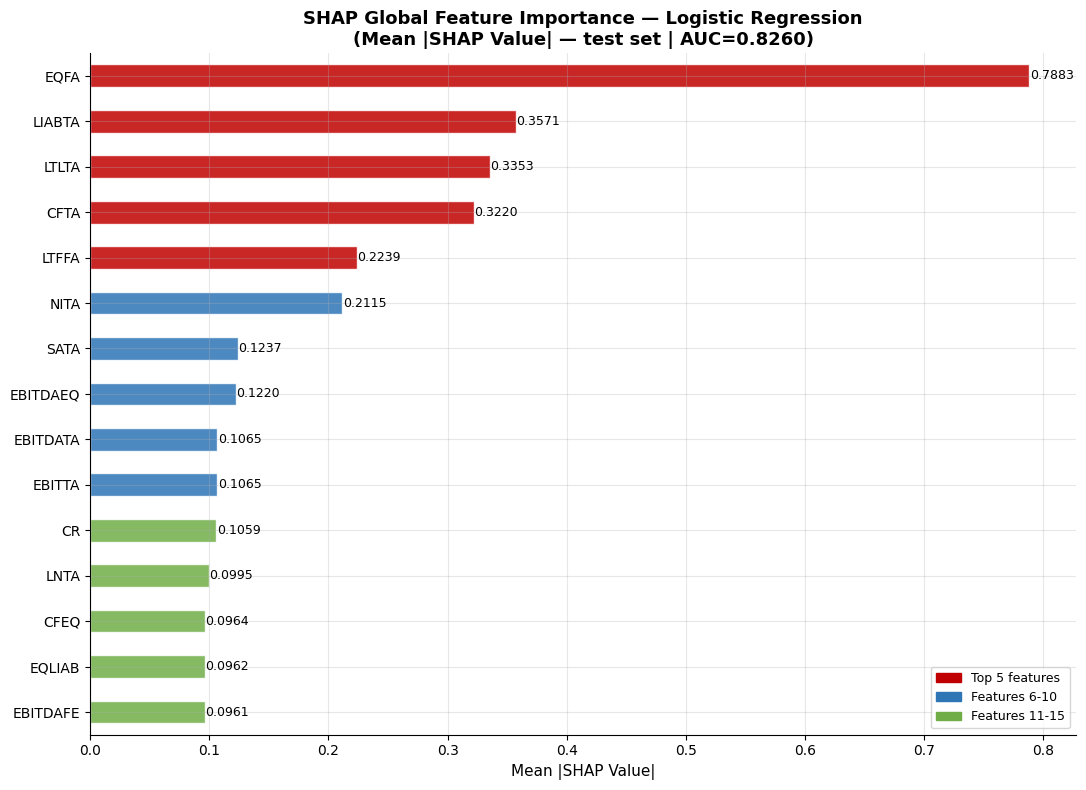

Saved: shap_01_importance.png


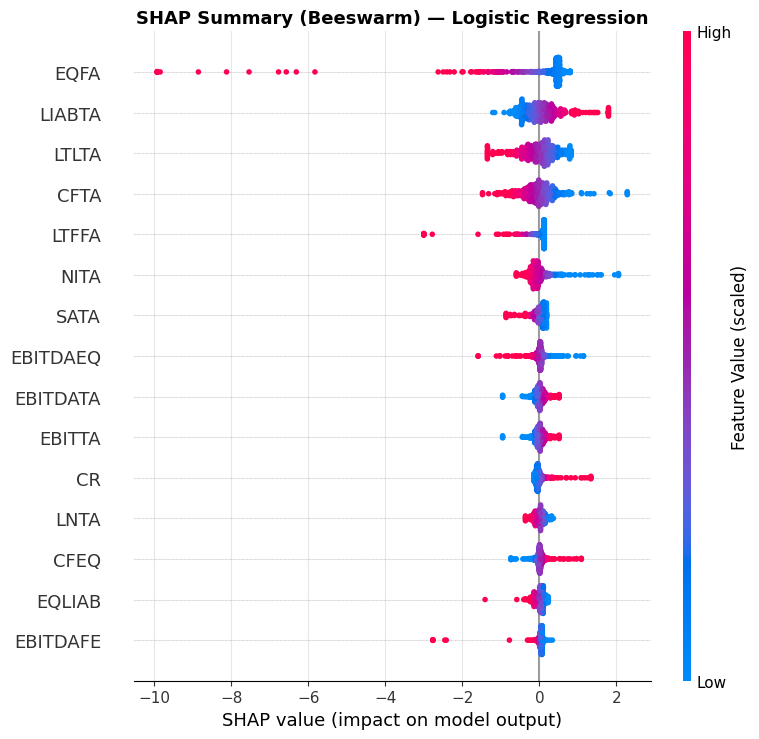

Saved: shap_02_beeswarm.png


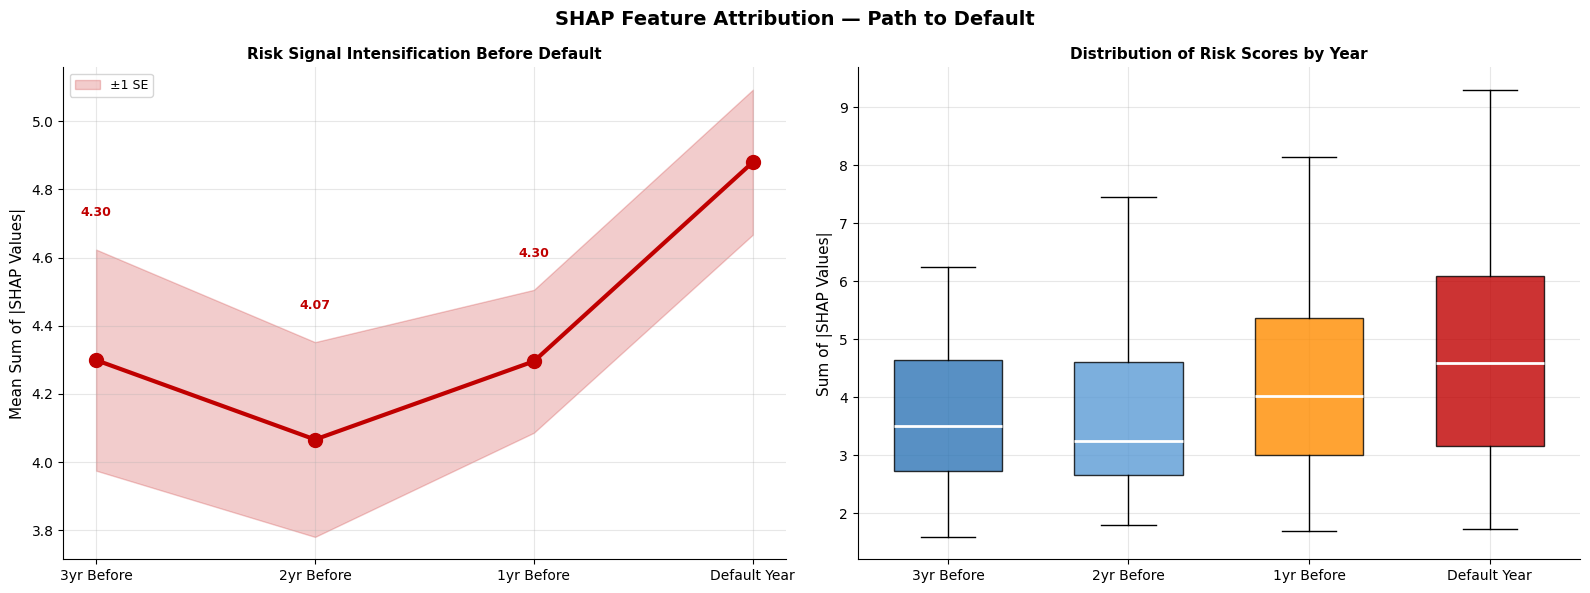

Saved: shap_03_trajectory.png
Saved: shap_importance.csv


In [ ]:
print("="*55)
print("RQ4: SHAP EXPLAINABILITY")
print("="*55)

import shap

# Find best model by test AUC
best_auc,best_name,best_pipe = 0,None,None
best_X_te,best_y_te,best_feats = None,None,None

for res,mods,X_te,y_te,feats in [
    (results_set1,models_set1,X_te1,y_te1,FEAT_SET1),
    (results_set2,models_set2,X_te2,y_te2,FEAT_SET2),
    (results_set3,models_set3,X_te3,y_te3,FEAT_SET3),
]:
    for name,pipe in mods.items():
        if name=='Altman Z-Score': continue
        auc=roc_auc_score(y_te.values,pipe.predict_proba(X_te)[:,1])
        if auc>best_auc:
            best_auc,best_name,best_pipe=auc,name,pipe
            best_X_te,best_y_te,best_feats=X_te,y_te,feats

print(f"Best model: {best_name} (Test AUC = {best_auc:.4f})")
steps     = {n:s for n,s in best_pipe.steps}
X_imp     = steps['imputer'].transform(best_X_te)
X_imp_df  = pd.DataFrame(X_imp, columns=best_feats)
underlying = steps['model']
mtype      = type(underlying).__name__

try:
    if 'Logistic' in mtype:
        X_sc    = steps['scaler'].transform(X_imp)
        X_sc_df = pd.DataFrame(X_sc, columns=best_feats)
        explainer   = shap.LinearExplainer(underlying, X_sc_df)
        sv          = explainer.shap_values(X_sc_df)
        X_for_plot  = X_sc_df
        print("LinearExplainer used (Logistic Regression)")
    else:
        explainer   = shap.TreeExplainer(underlying)
        shap_raw    = explainer.shap_values(X_imp_df)
        sv          = shap_raw[1] if isinstance(shap_raw,list) else shap_raw
        X_for_plot  = X_imp_df
        print(f"TreeExplainer used ({mtype})")

    mean_abs = np.abs(sv).mean(axis=0)
    shap_imp = pd.Series(mean_abs, index=best_feats).sort_values(ascending=False)
    print("\nTop 15 features:")
    print(shap_imp.head(15).round(4).to_string())

    # ── Fig 1: SHAP bar chart ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 8))
    top15   = shap_imp.head(15).sort_values(ascending=True)
    colors  = [C_DEF if i>=10 else C_NODEF if i>=5 else C_NEUT
               for i in range(len(top15))]
    top15.plot(kind='barh', ax=ax, color=colors, alpha=0.85, edgecolor='white')
    for i, (val, bar) in enumerate(zip(top15.values,
                                         ax.patches)):
        ax.text(val+0.0005, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(f'SHAP Global Feature Importance — {best_name}\n'
                 f'(Mean |SHAP Value| — test set | AUC={best_auc:.4f})',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
    patches = [mpatches.Patch(color=C_DEF, label='Top 5 features'),
               mpatches.Patch(color=C_NODEF, label='Features 6-10'),
               mpatches.Patch(color=C_NEUT, label='Features 11-15')]
    ax.legend(handles=patches, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/shap_01_importance.png',dpi=150,bbox_inches='tight',facecolor='white')
    plt.show()
    print("Saved: shap_01_importance.png")

    # ── Fig 2: SHAP beeswarm ──────────────────────────────────────────────────
    plt.figure(figsize=(11,8))
    shap.summary_plot(sv, X_for_plot, plot_type='dot', show=False,
                      max_display=15, color_bar_label='Feature Value (scaled)')
    plt.title(f'SHAP Summary (Beeswarm) — {best_name}',
              fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/shap_02_beeswarm.png',dpi=150,bbox_inches='tight',facecolor='white')
    plt.show()
    print("Saved: shap_02_beeswarm.png")

    # ── Fig 3: SHAP trajectory ────────────────────────────────────────────────
    X_tr_raw = train[best_feats].copy()
    X_tr_imp = pd.DataFrame(steps['imputer'].transform(X_tr_raw), columns=best_feats)
    if 'Logistic' in mtype:
        X_tr_sc  = pd.DataFrame(steps['scaler'].transform(X_tr_imp), columns=best_feats)
        sv_train = explainer.shap_values(X_tr_sc)
    else:
        sv_raw   = explainer.shap_values(X_tr_imp)
        sv_train = sv_raw[1] if isinstance(sv_raw,list) else sv_raw

    train_cp = train.copy().reset_index(drop=True)
    train_cp['shap_sum'] = np.abs(sv_train).sum(axis=1)

    traj=[]
    for tk in train_cp[train_cp.y_default==1]['Ticker'].unique():
        firm   = train_cp[train_cp.Ticker==tk].sort_values('Year')
        def_yr = firm[firm.y_default==1]['Year'].min()
        for lag in [3,2,1,0]:
            row = firm[firm.Year==def_yr-lag]
            if len(row)>0:
                traj.append({'Lag':lag,'shap_sum':row.iloc[0]['shap_sum']})

    traj_df=pd.DataFrame(traj)
    if len(traj_df)>0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('SHAP Feature Attribution — Path to Default',
                     fontsize=14, fontweight='bold')

        # Left: Trajectory line
        ax = axes[0]
        traj_m = traj_df.groupby('Lag')['shap_sum'].agg(['mean','sem'])
        lags   = traj_m.index[::-1].tolist()
        means  = traj_m['mean'][::-1].tolist()
        sems   = traj_m['sem'][::-1].tolist()
        ax.plot(range(len(lags)), means,'o-',color=C_DEF,lw=3,ms=10,zorder=3)
        ax.fill_between(range(len(lags)),
                         [m-s for m,s in zip(means,sems)],
                         [m+s for m,s in zip(means,sems)],
                         alpha=0.2,color=C_DEF,label='±1 SE')
        ax.set_xticks(range(len(lags)))
        ax.set_xticklabels(['3yr Before','2yr Before','1yr Before','Default Year'],fontsize=10)
        ax.set_ylabel('Mean Sum of |SHAP Values|',fontsize=11)
        ax.set_title('Risk Signal Intensification Before Default',fontweight='bold',fontsize=11)
        ax.legend(fontsize=9)
        for i,(m,s) in enumerate(zip(means,sems)):
            ax.annotate(f'{m:.2f}', (i,m+s+0.02*max(means)),
                         ha='center',fontsize=9,color=C_DEF,fontweight='bold')

        # Right: Box plot by year before default
        ax = axes[1]
        for lag,label,col,pos in [(3,'3yr Before',C_NODEF,1),(2,'2yr Before','#5B9BD5',2),
                                    (1,'1yr Before',C_WARN,3),(0,'Default Year',C_DEF,4)]:
            d = traj_df[traj_df.Lag==lag]['shap_sum'].dropna()
            bp = ax.boxplot([d], positions=[pos], patch_artist=True, widths=0.6,
                             showfliers=False,
                             medianprops=dict(color='white',lw=2))
            bp['boxes'][0].set_facecolor(col); bp['boxes'][0].set_alpha(0.8)
        ax.set_xticks([1,2,3,4])
        ax.set_xticklabels(['3yr Before','2yr Before','1yr Before','Default Year'],fontsize=10)
        ax.set_ylabel('Sum of |SHAP Values|',fontsize=11)
        ax.set_title('Distribution of Risk Scores by Year',fontweight='bold',fontsize=11)

        plt.tight_layout()
        plt.savefig(f'{OUTPUT}/shap_03_trajectory.png',dpi=150,bbox_inches='tight',facecolor='white')
        plt.show()
        print("Saved: shap_03_trajectory.png")

    shap_imp.reset_index().rename(
        columns={'index':'Feature',0:'Mean_Abs_SHAP'}
    ).to_csv(f'{OUTPUT}/shap_importance.csv',index=False)
    print("Saved: shap_importance.csv")

except Exception as e:
    import traceback
    print(f"SHAP error: {e}")
    traceback.print_exc()

## Final Summary

In [ ]:
print("="*55)
print("COMPLETE — v4")
print("="*55)
print(f"\nOutputs: {OUTPUT}")
print("  panel_cleaned.csv              — cleaned panel")
print("  macro_panel.csv                — FRED macro")
print("  model_results_all.csv          — all metrics")
print("  hypothesis_tests.csv           — DeLong tests")
print("  eda_descriptive_stats.csv      — descriptive stats")
print()
print("  eda_01_default_overview.png    — default distribution")
print("  eda_02_distributions.png       — KDE by default status")
print("  eda_03_boxplots.png            — annotated box plots")
print("  eda_04_correlation.png         — correlation heatmap")
print("  eda_05_trends.png              — trends over time")
print("  eda_06_missing_data.png        — missing data chart")
print("  eda_07_change_vars.png         — change variable distributions")
print("  eda_08_altman.png              — Altman Z-score analysis")
print()
print("  model_01_auc_comparison.png    — AUC bar charts")
print("  model_02_roc_curves.png        — ROC curves (3 sets)")
print("  model_03_metrics_heatmap.png   — metrics heatmap")
print()
print("  shap_01_importance.png         — SHAP global importance")
print("  shap_02_beeswarm.png           — SHAP beeswarm")
print("  shap_03_trajectory.png         — SHAP path to default")
print("  shap_importance.csv            — SHAP table")
print()
print("v4 changes:")
print("  Workflow order: Clean -> EDA -> Features -> Models")
print("  Change variables replace raw lags")
print("  QR read directly from FactSet")
print("  SHAP: LinearExplainer / TreeExplainer auto-selected")
print("  8 EDA charts + 3 model charts + 3 SHAP charts")

COMPLETE — v4

Outputs: /content/drive/MyDrive/DBA/Research/outputs
  panel_cleaned.csv              — cleaned panel
  macro_panel.csv                — FRED macro
  model_results_all.csv          — all metrics
  hypothesis_tests.csv           — DeLong tests
  eda_descriptive_stats.csv      — descriptive stats

  eda_01_default_overview.png    — default distribution
  eda_02_distributions.png       — KDE by default status
  eda_03_boxplots.png            — annotated box plots
  eda_04_correlation.png         — correlation heatmap
  eda_05_trends.png              — trends over time
  eda_06_missing_data.png        — missing data chart
  eda_07_change_vars.png         — change variable distributions
  eda_08_altman.png              — Altman Z-score analysis

  model_01_auc_comparison.png    — AUC bar charts
  model_02_roc_curves.png        — ROC curves (3 sets)
  model_03_metrics_heatmap.png   — metrics heatmap

  shap_01_importance.png         — SHAP global importance
  shap_02_beeswarm.